!pip install opencv-python opencv-contrib-python numpy matplotlib PyWavelets

# 2. Introduction to Wavelet Transformation

A wavelet transform is a way to study a signal or image using **small wave-like patterns** at different positions and different scales.

### Why do we need wavelets?

Suppose an image contains:
- a large smooth region,
- a small sharp corner,
- fine texture,
- and some sudden changes.

A single global frequency description may hide where those changes happen.

Wavelets let us ask:

> "What kind of frequency/detail exists, and **where** does it exist?"

This is especially useful for **non-stationary signals**, where the signal's behavior changes over time or position.

### Two important ideas

**Scale**
- Small scale -> fine details / small structures.
- Large scale -> coarse structure / broader patterns.

**Translation**
- Move the wavelet from one position to another to discover where a pattern exists.

### Two main types in the manual
- **CWT (Continuous Wavelet Transform)**
- **DWT (Discrete Wavelet Transform)**


## 2.1 Continuous Wavelet Transform (CWT)

### Simple idea

CWT continuously changes:
- the **scale** of the wavelet
- and its **position**

and checks how well the wavelet matches the signal.

You can think of it as taking a small shape and repeatedly:
1. stretching/shrinking it,
2. sliding it across the signal,
3. measuring how strongly it matches.

### Wavelet families

Different wavelets have different shapes and properties. The manual mentions the **Morlet wavelet**, which is useful for oscillatory behavior.

### Applications from the manual
- time-frequency analysis
- seismic signal analysis
- image analysis

### Exam point

**CWT = continuous scaling + continuous shifting of a wavelet across a signal.**

It gives detailed information about **where** a particular frequency-like pattern occurs.


## 2.2 Discrete Wavelet Transform (DWT)

DWT performs the wavelet analysis in a **discrete** manner.

Instead of checking every possible continuous scale and position, it works with selected discrete scales and shifts.

### Common wavelet families mentioned in the manual
- Daubechies
- Haar
- Symlet

### Why DWT is important

The manual lists:
- image compression
- image denoising
- feature extraction
- signal compression
- signal analysis

### Easy way to remember

**CWT -> more continuous / detailed search**

**DWT -> discrete / practical multiscale decomposition**

A classic idea in DWT is that the signal is separated into:
- low-frequency / coarse information
- high-frequency / detail information

For an image, these become approximation and detail subbands.


## 2.3 Wavelet Packet Transform (WPT)

WPT is an extension of DWT.

### Main idea

DWT usually keeps decomposing the important approximation branch recursively.

WPT gives a **more flexible decomposition** by allowing more branches/subbands to be decomposed.

So:

**DWT -> selective multiscale decomposition**

**WPT -> more flexible decomposition of multiple subbands**

The manual says WPT is useful for:
- complex frequency content
- feature extraction in machine learning

### MCQ idea

If the question says **"extension of DWT that allows more flexible subband decomposition"**, think **WPT**.


## 2.4 Inverse Wavelet Transform

The forward wavelet transform breaks the signal/image into wavelet coefficients.

The **inverse wavelet transform** performs the reverse operation:

**wavelet coefficients + required original information -> reconstructed signal/image**

### Why is this useful?

If you compress or denoise using wavelets, you eventually want an image/signal back.

That is where inverse transformation is used.

### MCQ idea

- Forward transform -> decomposition / analysis
- Inverse transform -> reconstruction


# 3. Boundary Detection (Edge Detection)

A **boundary** is a place where two regions meet and the image intensity changes noticeably.

Example:

A black object on a white background has a strong intensity change at its border.

### Why are edges useful?

Edges remove a lot of unnecessary information while keeping important structure such as:
- object boundaries
- shape outlines
- corners and structural details

So instead of processing every pixel equally, we can focus on **where intensity changes rapidly**.

### Important distinction

**Edge detection does NOT directly tell us "this is a car" or "this is a tree".**

It mainly tells us:

> "There is a strong change here."

Then later algorithms can use these structural clues.


# 3.1 Sobel Edge Detection

Sobel is a **gradient-based edge detector**.

The manual uses two 3x3 kernels:

### X-direction kernel

```text
[-1  0  1]
[-2  0  2]
[-1  0  1]
```

This responds strongly to intensity changes in the **x direction**.

### Y-direction kernel

```text
[-1 -2 -1]
[ 0  0  0]
[ 1  2  1]
```

This responds strongly to intensity changes in the **y direction**.

The outputs are commonly written as:

- **Gx** -> x-direction gradient
- **Gy** -> y-direction gradient

Then the overall edge strength is:

**G = sqrt(Gx^2 + Gy^2)**

### Very important intuition

- Large `Gx` -> strong change detected by the x-gradient kernel.
- Large `Gy` -> strong change detected by the y-gradient kernel.
- Large overall magnitude -> strong edge.

The signs also carry direction information, so keeping a signed floating-point result is useful during calculation.


## Sobel: the 3x3 neighborhood in simple words

For every pixel, Sobel looks at a small 3x3 neighborhood.

It gives larger weights to pixels closer to the center in the vertical-direction kernel and then computes a weighted difference.

A uniform area tends to give a near-zero response because there is little intensity change.

At a boundary, one side may be dark and the other side bright, so the weighted difference becomes large.

### Exam point

**Sobel = directional gradient calculation using convolution kernels.**


## Why does the Sobel code use `CV_64F`?

The manual uses:

`cv2.CV_64F`

Gradient values can be **negative**.

An unsigned 8-bit image cannot represent negative values properly.

`CV_64F` means the Sobel output is stored as 64-bit floating-point values, so negative and positive gradient values can be preserved during calculation.

Later, the code converts the final magnitude to an 8-bit display-friendly image.


# Sobel Code - Full Explanation

The following is the code shown in the manual, expanded with detailed comments.

### Main flow
1. Import libraries.
2. Read image.
3. Convert BGR -> RGB for Matplotlib display.
4. Convert image to grayscale.
5. Calculate Sobel X.
6. Calculate Sobel Y.
7. Combine both into gradient magnitude.
8. Clip values to 0-255.
9. Convert to `uint8`.
10. Display original, X-gradient, Y-gradient and final magnitude.


In [ ]:
# ============================================================
# SOBEL EDGE DETECTION
# Code based on the Sobel example in the supplied manual.
# ============================================================

# OpenCV:
# Used for reading images, color conversion and Sobel filtering.
import cv2

# NumPy:
# Used for numerical operations such as sqrt, clipping and
# changing the data type of the final image.
import numpy as np

# Matplotlib:
# Used only for displaying the images nicely in a notebook.
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. READ THE IMAGE
# ------------------------------------------------------------
# cv2.imread(filename, flags)
#
# filename:
#     Path/name of the image file.
#
# flags:
#     Default is cv2.IMREAD_COLOR (usually loads a 3-channel
#     color image in BGR order).
#
# Other common values:
#     cv2.IMREAD_GRAYSCALE / 0 -> load directly as grayscale
#     cv2.IMREAD_UNCHANGED / -1 -> keep the image as-is,
#                                  including alpha if available
#
# The manual specifically uses "image.jpeg" in the Sobel code.
image = cv2.imread("image.jpeg")


# ------------------------------------------------------------
# 2. CONVERT BGR -> RGB FOR MATPLOTLIB
# ------------------------------------------------------------
# OpenCV normally stores a color image as BGR:
#     Blue, Green, Red
#
# Matplotlib normally expects:
#     Red, Green, Blue
#
# cv2.cvtColor(src, code)
#     src  -> input image
#     code -> the requested color-space conversion
#
# COLOR_BGR2RGB:
#     Changes the channel order from BGR to RGB.
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# ------------------------------------------------------------
# 3. CONVERT TO GRAYSCALE
# ------------------------------------------------------------
# Sobel is applied to the grayscale intensity image.
#
# COLOR_BGR2GRAY:
#     Converts a 3-channel BGR image to one grayscale intensity
#     channel.
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# ------------------------------------------------------------
# 4. SOBEL IN THE X DIRECTION
# ------------------------------------------------------------
# cv2.Sobel(src, ddepth, dx, dy, ksize, scale=1, delta=0,
#           borderType=cv2.BORDER_DEFAULT)
#
# src:
#     Input image.
#
# ddepth:
#     Output data type/depth.
#     CV_64F is used here because gradient values may be
#     negative and we want to preserve them.
#
# dx:
#     Derivative order in the x direction.
#     1 -> calculate first derivative in x.
#
# dy:
#     Derivative order in y.
#     0 -> no derivative in y.
#
# ksize:
#     Size of the Sobel kernel.
#     Common values are 1, 3, 5, 7.
#     Larger kernels consider a larger neighborhood and
#     produce a different amount of smoothing/detail response.
#
# scale:
#     Optional multiplier applied to the derivative.
#     Default = 1.
#
# delta:
#     Optional value added to the result.
#     Default = 0.
#
# borderType:
#     Defines how OpenCV handles pixels near the image border.
#     Common choices include BORDER_DEFAULT, BORDER_CONSTANT,
#     BORDER_REPLICATE and BORDER_REFLECT.
#
# dx=1, dy=0 means X-direction derivative.
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)


# ------------------------------------------------------------
# 5. SOBEL IN THE Y DIRECTION
# ------------------------------------------------------------
# Here:
#     dx=0 -> no x derivative
#     dy=1 -> first y derivative
#
# This captures intensity changes in the other direction.
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)


# ------------------------------------------------------------
# 6. CALCULATE GRADIENT MAGNITUDE
# ------------------------------------------------------------
# Formula:
#
#     magnitude = sqrt(sobel_x^2 + sobel_y^2)
#
# np.sqrt(x):
#     Element-wise square root.
#
# **2:
#     Element-wise square.
#
# Adding the two squared directional gradients gives the total
# gradient strength at each pixel.
magnitude = np.sqrt(sobel_x**2 + sobel_y**2)


# ------------------------------------------------------------
# 7. CLIP THE VALUES FOR DISPLAY
# ------------------------------------------------------------
# np.clip(array, a_min, a_max)
#
# Any value below 0 becomes 0.
# Any value above 255 becomes 255.
# Values already inside the range stay unchanged.
#
# This is useful because a normal uint8 display image uses
# values from 0 to 255.
magnitude = np.uint8(np.clip(magnitude, 0, 255))


# ------------------------------------------------------------
# 8. PLOT THE RESULTS
# ------------------------------------------------------------
# plt.figure(figsize=(12, 8))
#     Creates a figure 12 inches wide and 8 inches high.
plt.figure(figsize=(12, 8))


# subplot(nrows, ncols, index)
#     Create a grid of plots and select one position.
#
# Here 2x2 means:
#     2 rows, 2 columns
#
# Position 1:
#     Original image
plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")

# axis("off"):
#     Hides x-axis and y-axis ticks/labels.
plt.axis("off")


# Position 2:
#     Sobel X output
#
# cmap="gray":
#     Display the single-channel image using a grayscale colormap.
plt.subplot(2, 2, 2)
plt.imshow(sobel_x, cmap="gray")
plt.title("Sobel X")
plt.axis("off")


# Position 3:
#     Sobel Y output
plt.subplot(2, 2, 3)
plt.imshow(sobel_y, cmap="gray")
plt.title("Sobel Y")
plt.axis("off")


# Position 4:
#     Final gradient magnitude
plt.subplot(2, 2, 4)
plt.imshow(magnitude, cmap="gray")
plt.title("Sobel Edge Magnitude")
plt.axis("off")


# tight_layout():
#     Automatically adjusts spacing so plot elements do not
#     overlap unnecessarily.
plt.tight_layout()

# show():
#     Actually display the figure.
plt.show()


## Sobel parameters - what changes if you change them?

### `ksize`
- `3` -> small 3x3 neighborhood, common choice.
- `5` -> larger neighborhood, smoother/slightly broader response.
- `7` -> even larger neighborhood.
- `1` -> special smallest Sobel aperture.
- `-1` -> commonly associated with using the Scharr operator rather than normal Sobel.

### `dx` and `dy`
- `(1, 0)` -> X derivative.
- `(0, 1)` -> Y derivative.
- Higher derivative orders are possible, but the manual is teaching first derivatives.

### `CV_64F`
Useful when you need signed gradient values.

### `np.clip(..., 0, 255)`
Makes sure the final displayed values fit in the normal 8-bit image range.

### `np.uint8(...)`
Converts values to unsigned 8-bit integers, the common format for displayable grayscale images.


# 3.2 Canny Edge Detection

Canny is more sophisticated than simply applying a gradient filter.

The manual describes these stages:

1. **Gaussian smoothing**
2. **Gradient calculation**
3. **Non-maximum suppression**
4. **Hysteresis thresholding**

### 1. Gaussian smoothing

First, blur the image slightly.

Why?

Noise can create false edges. Blurring reduces small unwanted intensity variations before edge detection.

### 2. Gradient calculation

The algorithm calculates:
- gradient magnitude -> how strong the change is
- gradient direction -> which way the change is happening

### 3. Non-maximum suppression

Even after gradient calculation, an edge may appear several pixels thick.

NMS keeps only local maximum responses along the edge direction.

So:

**thick edge -> thin edge**

### 4. Hysteresis thresholding

Canny uses two thresholds:
- lower threshold
- upper threshold

Pixels above the upper threshold are strong edges.

Pixels below the lower threshold are usually rejected.

Pixels between them are weak candidates and are kept when they are connected to strong edges.

This connectivity step helps Canny produce thin and continuous edges.


## Canny: easy example

Suppose the edge strength along a line is:

`200, 150, 140, 50, 20`

If the edge direction says that `200` is the local maximum, non-maximum suppression can keep the strongest pixel and suppress nearby weaker values.

Then hysteresis decides which weak candidates are connected to strong edges.

### Main benefit of Canny over simple Sobel

Sobel mainly gives gradient responses.

Canny adds a **full edge-selection pipeline**, which usually gives cleaner, thinner and more connected edge maps.


# Canny Code - Full Explanation

The following reproduces the code shown in the manual and adds detailed comments.

### Important file-name note

The Sobel example in the manual uses `image.jpeg`, while the Canny, LoG and SIFT code use `image.jpg`.

That difference is in the supplied manual. If your actual file is named only one of these, use that real filename consistently when you run the notebook.


In [ ]:
# ============================================================
# CANNY EDGE DETECTION
# Code based on the Canny example in the supplied manual.
# ============================================================

import cv2
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. READ IMAGE
# ------------------------------------------------------------
# The Canny section of the manual uses "image.jpg".
image = cv2.imread("image.jpg")


# ------------------------------------------------------------
# 2. CONVERT BGR -> RGB FOR MATPLOTLIB
# ------------------------------------------------------------
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# ------------------------------------------------------------
# 3. CONVERT TO GRAYSCALE
# ------------------------------------------------------------
# Canny works on a single-channel grayscale image.
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# ------------------------------------------------------------
# 4. GAUSSIAN BLUR
# ------------------------------------------------------------
# cv2.GaussianBlur(src, ksize, sigmaX, sigmaY=0,
#                  borderType=cv2.BORDER_DEFAULT)
#
# src:
#     Input image.
#
# ksize:
#     Gaussian kernel size.
#     It should normally be positive and odd, for example
#     (3,3), (5,5), (7,7).
#
# sigmaX:
#     Standard deviation of the Gaussian in the x direction.
#     Larger sigma -> more smoothing.
#
# sigmaY:
#     Standard deviation in y.
#     If left at 0, OpenCV derives it from sigmaX/ksize.
#
# The manual uses:
#     (5,5) -> 5x5 blur window
#     1.4   -> sigmaX
#
# The purpose is to reduce noise before edge detection.
blurred = cv2.GaussianBlur(gray, (5, 5), 1.4)


# ------------------------------------------------------------
# 5. CANNY EDGE DETECTION
# ------------------------------------------------------------
# cv2.Canny(image, threshold1, threshold2,
#           apertureSize=3, L2gradient=False)
#
# image:
#     Usually the blurred grayscale image.
#
# threshold1:
#     Lower hysteresis threshold.
#
# threshold2:
#     Upper hysteresis threshold.
#
# apertureSize:
#     Aperture size used internally for the Sobel gradient.
#     Common values: 3, 5, 7.
#
# L2gradient:
#     False -> uses the standard approximate magnitude.
#     True  -> uses the more mathematically precise
#              sqrt(Gx^2 + Gy^2) style magnitude.
#
# Manual values:
#     lower threshold = 50
#     upper threshold = 150
#
# A common rule is that the upper threshold is larger than
# the lower threshold.
edges = cv2.Canny(
    blurred,
    50,     # Lower threshold
    150     # Upper threshold
)


# ------------------------------------------------------------
# 6. DISPLAY RESULTS
# ------------------------------------------------------------
plt.figure(figsize=(12, 8))


# Original RGB image
plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")


# Grayscale image
plt.subplot(2, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")


# Gaussian-smoothed grayscale image
plt.subplot(2, 2, 3)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred")
plt.axis("off")


# Final Canny edge map
plt.subplot(2, 2, 4)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")


# Adjust spacing and show.
plt.tight_layout()
plt.show()


## Canny parameters - very important

### `GaussianBlur(gray, (5,5), 1.4)`

**Kernel size**
- `(3,3)` -> less smoothing
- `(5,5)` -> moderate smoothing
- `(7,7)` -> more smoothing

**sigmaX**
- small -> less blur
- larger -> more blur

Too much blur can erase real small edges.

### `Canny(blurred, 50, 150)`

**Lower threshold = 50**

Controls the beginning of the hysteresis range.

**Upper threshold = 150**

Controls what is considered a strong edge.

#### What happens if thresholds increase?
You generally become more selective:
- fewer weak edges
- less noise
- but very weak real edges may disappear

#### What happens if thresholds decrease?
You generally detect more edges:
- more detail
- but potentially more noise and false edges

The exact best values depend on the image.


# 3.3 Laplacian of Gaussian (LoG)

LoG means **Laplacian of Gaussian**.

The manual's idea is:

**Gaussian smoothing -> Laplacian -> look for zero-crossings / edge locations**

### Why Gaussian first?

Noise produces rapid intensity changes too.

The Gaussian filter smooths small noisy variations so that the second-derivative operation does not react too strongly to noise.

### Why Laplacian?

The Laplacian is a **second derivative**.

The manual contrasts:
- first derivative / gradient -> rate of intensity change
- second derivative / Laplacian -> rate at which that change itself changes

For edge localization, **zero-crossings** of the second derivative are important.

### Easy intuition

Imagine intensity changes from dark to bright.

- First derivative becomes large around the transition.
- Second derivative changes sign around the transition.
- That sign change is a zero-crossing and can indicate an edge.

### LoG pipeline from the manual

**Image -> Gaussian blur -> Laplacian -> zero-crossing based edge interpretation**


# LoG Code - Full Explanation

The following reproduces the LoG code from the manual.

### Key point

`cv2.Laplacian()` produces a signed derivative response, so the manual uses:

`cv2.convertScaleAbs()`

for a clean display.

That display operation is not the same thing as the mathematical zero-crossing detector itself. It mainly converts the response into an easy-to-display 8-bit image.


In [ ]:
# ============================================================
# LAPLACIAN OF GAUSSIAN (LoG)
# Code based on the LoG example in the supplied manual.
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. READ IMAGE
# ------------------------------------------------------------
image = cv2.imread("image.jpg")


# ------------------------------------------------------------
# 2. CONVERT BGR -> RGB FOR MATPLOTLIB
# ------------------------------------------------------------
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# ------------------------------------------------------------
# 3. CONVERT TO GRAYSCALE
# ------------------------------------------------------------
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# ------------------------------------------------------------
# 4. STEP 1: GAUSSIAN BLUR
# ------------------------------------------------------------
# Same idea as in Canny:
# remove small noisy intensity variations before applying
# a derivative operator.
#
# ksize = (5,5)
# sigmaX = 1.4
blurred = cv2.GaussianBlur(gray, (5, 5), 1.4)


# ------------------------------------------------------------
# 5. STEP 2: APPLY LAPLACIAN
# ------------------------------------------------------------
# cv2.Laplacian(src, ddepth, ksize=1, scale=1,
#               delta=0, borderType=cv2.BORDER_DEFAULT)
#
# src:
#     Input image.
#
# ddepth:
#     Depth/type of the destination image.
#     CV_64F is used so signed second-derivative values
#     are preserved during calculation.
#
# ksize:
#     Aperture size for the Laplacian.
#     Common odd sizes include 1, 3, 5, 7.
#
# scale:
#     Optional scale factor applied to the computed values.
#
# delta:
#     Optional value added to the output.
#
# borderType:
#     Specifies how image borders are handled.
#
# The supplied manual uses CV_64F and the default Laplacian
# kernel size.
laplacian = cv2.Laplacian(
    blurred,
    cv2.CV_64F
)


# ------------------------------------------------------------
# 6. ABSOLUTE VALUES FOR VISUALIZATION
# ------------------------------------------------------------
# cv2.convertScaleAbs(src, alpha=1.0, beta=0)
#
# It:
#   1. takes the absolute value,
#   2. scales the result by alpha,
#   3. adds beta,
#   4. converts it to 8-bit.
#
# This is useful for display.
#
# alpha:
#     Scaling factor (default 1).
#
# beta:
#     Brightness offset (default 0).
#
# IMPORTANT:
# This display conversion is different from explicitly finding
# mathematical zero-crossings in the signed Laplacian.
laplacian_abs = cv2.convertScaleAbs(laplacian)


# ------------------------------------------------------------
# 7. DISPLAY RESULTS
# ------------------------------------------------------------
plt.figure(figsize=(12, 8))


# Original color image
plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")


# Grayscale image
plt.subplot(2, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")


# Smoothed image
plt.subplot(2, 2, 3)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred")
plt.axis("off")


# Absolute Laplacian response
plt.subplot(2, 2, 4)
plt.imshow(laplacian_abs, cmap="gray")
plt.title("Laplacian of Gaussian (LoG)")
plt.axis("off")


plt.tight_layout()
plt.show()


## Sobel vs Canny vs LoG - must-know comparison

| Method | Main idea | Main strength | Important idea |
|---|---|---|---|
| Sobel | First derivative / gradient | Simple and fast directional gradients | Gx, Gy, magnitude |
| Canny | Multi-stage edge detector | Thin, connected, cleaner edges | Blur -> gradient -> NMS -> hysteresis |
| LoG | Gaussian + second derivative | Uses second-derivative behavior and zero-crossings | Blur -> Laplacian |

### Fast memory trick

**Sobel = "How fast is intensity changing?"**

**Laplacian = "How is that change itself changing?"**

**Canny = "Do all the important edge-cleaning steps and give me a good final edge map."**


# 4. Introduction to Hough Transform

The Hough Transform is used to detect shapes, especially:
- lines
- circles
- ellipses

The key idea is to move from the **image space** into a **parameter space**.

### Why is this useful?

Traditional edge detection says:

> "These pixels look like an edge."

Hough Transform tries to go one step further:

> "These edge pixels together form a line/circle."

### Very simple intuition

Imagine several edge pixels lying on the same straight line.

Instead of treating them as unrelated points, Hough voting lets those points **vote for the line parameters** that could explain them.

A strong cluster of votes indicates a likely shape.


## 4.1 Hough Transform for Line Detection

The supplied manual introduces the line as:

**y = mx + b**

where:
- `m` = slope
- `b` = y-intercept

### Parameter space

Instead of representing a line using every `(x,y)` pixel, the line becomes one point in a parameter space described by parameters such as `(m,b)`.

### Voting

For every edge pixel, we ask:

> "Which possible lines could pass through this pixel?"

Each possible line adds a vote to its corresponding parameter-space cell.

If many edge pixels agree on the same line, that parameter combination receives many votes.

### Peak detection

Large peaks in the parameter space correspond to likely lines.

### Back-transformation

Once a line is found in parameter space, we convert its parameters back to image coordinates to draw or interpret the line.

### Practical note

The manual teaches the `y = mx + b` representation because it is easy to understand.

In many practical Hough implementations, a polar form `(rho, theta)` is preferred because the slope-intercept form has difficulty naturally representing vertical lines. This is a practical extension, not a replacement for the manual's explanation.


## 4.2 Hough Transform for Circle Detection

The manual uses the circle equation:

**(x-a)^2 + (y-b)^2 = r^2**

where:
- `(a,b)` = center
- `r` = radius

### Parameter space

A circle has **three parameters**:
- `a`
- `b`
- `r`

So the parameter space is 3-dimensional.

### Voting

Each edge pixel votes for possible:
- centers
- radii

A strong peak indicates a likely circle.

### Back-transformation

After detecting the `(a,b,r)` values, the circle can be drawn back on the original image.

### MCQ trigger

For a circle in the manual:

**parameters = center x + center y + radius = 3 parameters**


# 5. SIFT (Scale-Invariant Feature Transform)

SIFT is a feature-extraction and matching technique.

Instead of describing the whole image with one vector, SIFT finds many **interesting local points**, called **keypoints**, and creates a descriptor for each one.

### Why is SIFT powerful?

A good local feature should ideally still be useful when:
- the object changes size
- the object is rotated
- lighting changes somewhat
- the viewpoint changes somewhat

The manual emphasizes applications such as:
- object recognition
- image stitching
- tracking


## 5.1 Scale-Space Extrema Detection

SIFT searches for candidate keypoints at multiple scales.

The manual uses the **Difference of Gaussians (DoG)** idea.

### DoG intuition

Create blurred versions of the image using different Gaussian scales and subtract nearby scales:

**DoG = Gaussian-blurred image at one scale - Gaussian-blurred image at another scale**

This helps highlight structures that are distinctive at particular scales.

### Why multiple scales?

A feature may be:
- small in one image,
- large in another.

Searching across scales helps SIFT find it more reliably.

### MCQ trigger

**DoG = Difference of two Gaussian-blurred images.**


## 5.2 Keypoint Localization

After candidate extrema are found, SIFT refines their location.

The manual describes a **26-neighbor check**.

### Why 26?

A candidate is compared with:
- 8 neighbors in the same scale layer
- 9 neighbors in the layer above
- 9 neighbors in the layer below

Total:

**8 + 9 + 9 = 26**

The candidate should behave like a local maximum or minimum relative to these neighbors.

This helps reject unstable or poorly localized candidates and gives more accurate keypoint positions.


## 5.3 Orientation Assignment

SIFT assigns a dominant orientation to every keypoint.

### Why?

Suppose the same object is rotated.

If the descriptor were built in the image's original coordinate direction, its representation would change dramatically.

Instead, SIFT measures local gradient directions and chooses a dominant orientation.

Then the local descriptor is built relative to that orientation.

Result:

**more rotation invariance**

### Memory trick

**Scale invariance -> search at multiple scales**

**Rotation invariance -> assign a canonical/dominant orientation**


## 5.4 Keypoint Descriptor Generation

Now SIFT describes the local neighborhood around each keypoint.

The manual describes a **4 x 4** arrangement of subregions, with **8 orientation bins** for each subregion.

Therefore:

**4 x 4 x 8 = 128 numbers**

So a standard SIFT descriptor is a **128-dimensional vector**.

### Why a descriptor?

A keypoint coordinate alone is not enough.

Two images may have a similar-looking feature at different coordinates.

The descriptor captures local gradient structure so descriptors can later be compared.

### What is stored?

The descriptor summarizes:
- local gradient magnitude
- local gradient orientation
- their distribution in small regions around the keypoint


## 5.5 Keypoint Matching

After descriptors are obtained from two images, compare descriptors.

The manual mentions **Euclidean distance** as one common similarity measure.

### Simple intuition

If two descriptors are very similar:
- their distance is small
- they are a better candidate match

If descriptors are very different:
- their distance is large
- they are less likely to represent the same local feature

### Important

Matching happens between **descriptors**, not merely raw pixel locations.


## 5.6 Outlier Rejection

Not every descriptor match is correct.

Wrong matches can happen because of:
- lighting changes
- viewpoint changes
- noise
- repeated patterns
- visually similar regions

The manual mentions **RANSAC (Random Sample Consensus)**.

### Main idea of RANSAC

Repeatedly:
1. choose a small random subset of matches,
2. estimate a geometric transformation,
3. check how many other matches agree with that transformation,
4. keep the transformation with the strongest consistent support.

Matches that do not agree are treated as **outliers**.

### Easy memory trick

**RANSAC = find a transformation that many matches agree with, reject the ones that do not.**


## 5.7 Final Matching and Homography Estimation

After outlier rejection, the remaining reliable matches can be used to estimate a transformation between the images.

The manual calls this **homography**.

A homography is especially useful for situations where one image can be related to another through a projective transformation, such as:
- image stitching
- planar object matching
- perspective-related alignment

### Whole SIFT pipeline

**Scale-space extrema detection**
-> **keypoint localization**
-> **orientation assignment**
-> **descriptor generation**
-> **keypoint matching**
-> **outlier rejection**
-> **homography / final geometric estimation**


# SIFT Code - Full Explanation

This is the complete SIFT example shown in the manual.

### Important note

The supplied manual's SIFT code **detects and visualizes keypoints**. It does not implement the complete two-image descriptor matching + RANSAC + homography pipeline discussed in the theory section.

So do not confuse:
- **SIFT feature extraction code here**
with
- **full SIFT matching / homography workflow**


In [ ]:
# ============================================================
# SIFT FEATURE EXTRACTION
# Code based on the SIFT example in the supplied manual.
# ============================================================

import cv2
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. READ IMAGE
# ------------------------------------------------------------
# The SIFT section of the manual uses "image.jpg".
image = cv2.imread("image.jpg")


# ------------------------------------------------------------
# 2. CONVERT BGR -> RGB FOR MATPLOTLIB
# ------------------------------------------------------------
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# ------------------------------------------------------------
# 3. CONVERT TO GRAYSCALE
# ------------------------------------------------------------
# SIFT detection is performed on a grayscale image.
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# ------------------------------------------------------------
# 4. CREATE THE SIFT DETECTOR
# ------------------------------------------------------------
# cv2.SIFT_create(
#     nfeatures=0,
#     nOctaveLayers=3,
#     contrastThreshold=0.04,
#     edgeThreshold=10,
#     sigma=1.6
# )
#
# The manual calls SIFT_create() with no arguments, so OpenCV
# uses its default parameter values.
#
# Important parameters you can control:
#
# nfeatures:
#     Maximum number of strongest features to keep.
#     0 means no explicit maximum is requested.
#
# nOctaveLayers:
#     Number of scale layers per octave.
#     More layers -> more scale sampling.
#
# contrastThreshold:
#     Rejects low-contrast candidates.
#     Higher value -> fewer weak keypoints.
#
# edgeThreshold:
#     Controls filtering of unstable edge-like features.
#     Higher values are generally more tolerant of edge-like
#     features.
#
# sigma:
#     Gaussian smoothing used for the initial scale.
#
# Here we intentionally follow the manual:
sift = cv2.SIFT_create()


# ------------------------------------------------------------
# 5. DETECT KEYPOINTS AND COMPUTE DESCRIPTORS
# ------------------------------------------------------------
# sift.detectAndCompute(image, mask)
#
# image:
#     Grayscale image on which SIFT is run.
#
# mask:
#     Defines where SIFT is allowed to search.
#     None means use the whole image.
#
# Returns:
#     keypoints   -> a list of detected cv2.KeyPoint objects
#     descriptors -> descriptor matrix; standard SIFT
#                    descriptors are 128-dimensional.
keypoints, descriptors = sift.detectAndCompute(gray, None)


# ------------------------------------------------------------
# 6. DRAW KEYPOINTS
# ------------------------------------------------------------
# cv2.drawKeypoints(
#     image,
#     keypoints,
#     outImage,
#     color=None,
#     flags=cv2.DRAW_MATCHES_FLAGS_DEFAULT
# )
#
# image:
#     Image on which keypoints are drawn.
#
# keypoints:
#     KeyPoint objects returned by SIFT.
#
# outImage:
#     Destination image.
#     None tells OpenCV to create one.
#
# color:
#     Optional drawing color.
#
# flags:
#     Controls how keypoints are drawn.
#
# DRAW_RICH_KEYPOINTS:
#     Draws the keypoint size and orientation as well as the
#     point itself, making the visualization more informative.
image_keypoints = cv2.drawKeypoints(
    image_rgb,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)


# ------------------------------------------------------------
# 7. DISPLAY
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))


# Left: original image
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")


# Right: original image with SIFT keypoints
plt.subplot(1, 2, 2)
plt.imshow(image_keypoints)
plt.title("SIFT Keypoints")
plt.axis("off")


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. PRINT BASIC INFORMATION
# ------------------------------------------------------------
# len(keypoints):
#     Number of detected keypoints.
#
# descriptors.shape:
#     Gives the descriptor matrix dimensions.
#     For N keypoints, standard SIFT normally gives:
#         (N, 128)
#
# This means:
#     N      = number of detected features
#     128    = descriptor length for each feature
print("Number of keypoints:", len(keypoints))
print("Descriptor shape:", descriptors.shape)


## SIFT parameters - what happens when they change?

The manual calls `cv2.SIFT_create()` without parameters, so defaults are used.

Useful parameters to know:

### `nfeatures`
Maximum number of strongest features to retain.
- smaller -> fewer keypoints
- larger -> more keypoints can be retained

### `nOctaveLayers`
Controls the number of layers within each octave.
- more -> finer scale sampling
- but potentially more computation

### `contrastThreshold`
Rejects weak-contrast features.
- higher -> fewer low-contrast keypoints
- lower -> more candidates, possibly more unstable/noisy ones

### `edgeThreshold`
Controls rejection of edge-like unstable features.
- important because a point that is only distinctive along an edge can be less stable than a true corner/blob-like feature

### `sigma`
Initial Gaussian smoothing scale.

### `mask` in `detectAndCompute`
- `None` -> search everywhere
- a binary mask -> restrict detection to selected regions


# Function Parameter Cheat Sheet

## OpenCV functions used in the manual

### `cv2.imread(filename, flags)`
**Purpose:** load an image.

Common `flags`:
- `cv2.IMREAD_COLOR` / `1` -> color image
- `cv2.IMREAD_GRAYSCALE` / `0` -> grayscale
- `cv2.IMREAD_UNCHANGED` / `-1` -> preserve channels including alpha when present

### `cv2.cvtColor(src, code)`
**Purpose:** convert between color spaces.

Important codes here:
- `cv2.COLOR_BGR2RGB`
- `cv2.COLOR_BGR2GRAY`

### `cv2.Sobel(src, ddepth, dx, dy, ksize, scale=1, delta=0, borderType=...)`
**Purpose:** calculate directional image derivatives / gradients.

Key arguments:
- `src` -> input image
- `ddepth` -> output depth
- `dx` -> x derivative order
- `dy` -> y derivative order
- `ksize` -> Sobel aperture
- `scale` -> multiplier
- `delta` -> value added to result
- `borderType` -> border handling

### `cv2.GaussianBlur(src, ksize, sigmaX, sigmaY=0, borderType=...)`
**Purpose:** Gaussian smoothing.

Important:
- larger kernel / sigma -> stronger smoothing

### `cv2.Canny(image, threshold1, threshold2, apertureSize=3, L2gradient=False)`
**Purpose:** multi-stage edge detection.

Important:
- `threshold1` -> lower hysteresis threshold
- `threshold2` -> upper hysteresis threshold
- `apertureSize` -> gradient kernel size
- `L2gradient=True` -> more direct Euclidean gradient magnitude

### `cv2.Laplacian(src, ddepth, ksize=1, scale=1, delta=0, borderType=...)`
**Purpose:** second-derivative / Laplacian response.

### `cv2.convertScaleAbs(src, alpha=1.0, beta=0)`
**Purpose:** absolute-value + scaling + conversion to 8-bit display form.

### `cv2.SIFT_create(...)`
**Purpose:** create a SIFT feature detector/descriptor extractor.

### `sift.detectAndCompute(image, mask)`
**Purpose:** detect keypoints and calculate their descriptors.

### `cv2.drawKeypoints(image, keypoints, outImage, color=None, flags=...)`
**Purpose:** visualize keypoints.

---

## NumPy functions used in the manual

### `np.sqrt(x)`
Element-wise square root.

### `np.clip(a, min, max)`
Restrict every value to a specified range.

### `np.uint8(x)`
Convert values to unsigned 8-bit integers.

---

## Matplotlib functions used in the manual

### `plt.figure(figsize=(w,h))`
Creates a figure.

### `plt.subplot(rows, cols, index)`
Chooses one position in a grid.

### `plt.imshow(image, cmap=...)`
Displays an image.

### `plt.title(text)`
Adds a title.

### `plt.axis("off")`
Hides axes.

### `plt.tight_layout()`
Improves spacing.

### `plt.show()`
Displays the figure.


# High-Value MCQ / Viva Cheat Sheet

### Wavelets
- CWT -> continuous scale + translation
- DWT -> discrete wavelet decomposition
- WPT -> more flexible/more extensive subband decomposition
- Inverse wavelet transform -> reconstruction

### Sobel
- Gradient-based
- Uses directional kernels
- `Gx` and `Gy`
- Magnitude = `sqrt(Gx^2 + Gy^2)`
- Common kernels are 3x3
- `CV_64F` is useful to preserve signed gradients

### Canny
Order:
1. Gaussian smoothing
2. Gradient calculation
3. Non-maximum suppression
4. Hysteresis thresholding

- Goal -> thin, connected and cleaner edges
- Two thresholds -> lower + upper

### LoG
- Gaussian smoothing + Laplacian
- Laplacian = second derivative
- Edge interpretation involves zero-crossings
- Often useful across varying scales

### Hough
- Image space -> parameter space
- Voting -> accumulate evidence
- Peaks -> likely shapes
- Line in the manual -> `y = mx + b`
- Circle -> `(x-a)^2 + (y-b)^2 = r^2`

### SIFT
Pipeline:
1. Scale-space extrema detection
2. Keypoint localization
3. Orientation assignment
4. Descriptor generation
5. Matching
6. Outlier rejection
7. Homography / final transformation estimation

Important numbers:
- keypoint localization -> 26 neighbors
- descriptor -> `4 x 4 x 8 = 128` values

### RANSAC
- robust model estimation
- separates consistent matches (inliers) from inconsistent matches (outliers)

### Homography
- geometric transformation between images
- useful for image stitching / planar alignment


# Common Mistakes to Avoid

### 1. Forgetting BGR vs RGB
OpenCV reads color images as **BGR**, while Matplotlib normally displays **RGB**.

So:
`cv2.cvtColor(image, cv2.COLOR_BGR2RGB)`

is for correct display.

### 2. Applying Sobel/Canny/LoG to the wrong image type
The manual converts to grayscale first because edge analysis is primarily based on intensity changes.

### 3. Losing negative gradient information too early
For gradient calculations, do not immediately force signed results into `uint8`.

That is why `CV_64F` is useful in the manual.

### 4. Confusing Sobel with Canny
Sobel gives directional gradient responses.

Canny is a complete multi-stage edge detector.

### 5. Confusing LoG visualization with actual zero-crossing extraction
`convertScaleAbs()` makes the signed Laplacian easier to display; it does not itself explicitly build a binary zero-crossing edge map.

### 6. Thinking SIFT keypoint count is fixed
It depends on:
- image content
- scale
- thresholds
- detector settings

### 7. Thinking descriptor = keypoint
They are different:
- **Keypoint** -> where/what local feature location was detected
- **Descriptor** -> numerical description of the local neighborhood

### 8. Forgetting the manual's file-name difference
Sobel example: `image.jpeg`

Canny / LoG / SIFT examples: `image.jpg`

Use the real file name on your machine.


# Final Mental Picture

Imagine an image containing a building.

**Wavelet**
-> tells you about image information at different scales.

**Sobel**
-> tells you where intensity changes and in which directional components.

**Canny**
-> cleans those gradient responses and produces a thin/connected edge map.

**LoG**
-> uses Gaussian smoothing followed by a second derivative and edge-related zero-crossings.

**Hough**
-> takes edge evidence and asks whether many edge pixels agree on a common line/circle.

**SIFT**
-> finds local distinctive features, describes them numerically, and allows matching between images.

That is the conceptual story of the entire supplied manual.


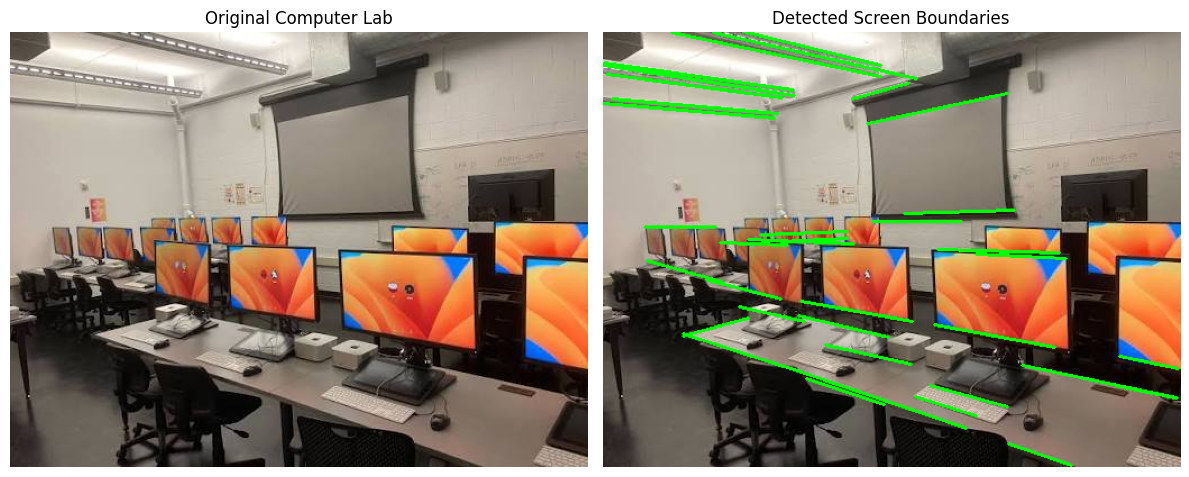

In [4]:
# Task # 01
# ============================================================
# TASK 1
# COMPUTER SCREEN DETECTION USING HOUGH LINE TRANSFORM
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# STEP 1: IMAGE READ KARNA
# ------------------------------------------------------------

# cv2.imread()
#
# Function:
# Image ko file se read/load karta hai.
#
# Syntax:
# cv2.imread(filename, flags)
#
# filename:
# Image ka path/name.
#
# flags:
# 1  = color image
# 0  = grayscale image
# -1 = image ko original channels ke sath read karta hai
#
# Yahan hum color image read kar rahe hain.
image = cv2.imread("computers.jfif")


# Agar image load nahi hui to image None hogi.
if image is None:
    print("Image not found!")
else:

    # --------------------------------------------------------
    # STEP 2: BGR IMAGE KO RGB MEIN CONVERT KARNA
    # --------------------------------------------------------

    # OpenCV images ko BGR format mein read karta hai.
    # Matplotlib RGB format expect karta hai.
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )


    # --------------------------------------------------------
    # STEP 3: GRAYSCALE
    # --------------------------------------------------------

    # Hough aur edge detection ke liye grayscale image
    # use karna easy hota hai.
    #
    # COLOR_BGR2GRAY:
    # BGR image ko grayscale mein convert karta hai.
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # --------------------------------------------------------
    # STEP 4: GAUSSIAN BLUR
    # --------------------------------------------------------

    # Blur noise ko reduce karta hai.
    #
    # GaussianBlur(image, kernel_size, sigmaX)
    #
    # (5,5):
    # 5x5 neighborhood use hoga.
    #
    # sigmaX = 0:
    # OpenCV khud sigma calculate karega.
    blurred = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )


    # --------------------------------------------------------
    # STEP 5: CANNY EDGE DETECTION
    # --------------------------------------------------------

    # Hough Transform ko normally edge image deni hoti hai.
    #
    # Canny(image, threshold1, threshold2)
    #
    # threshold1:
    # Lower threshold.
    #
    # threshold2:
    # Upper threshold.
    #
    # In dono ko change karke detected edges control
    # ki ja sakti hain.
    edges = cv2.Canny(
        blurred,
        50,
        150
    )


    # --------------------------------------------------------
    # STEP 6: HOUGH LINE TRANSFORM
    # --------------------------------------------------------

    # HoughLinesP:
    # Image mein straight line segments detect karta hai.
    #
    # Parameters:
    #
    # edges:
    # Canny se nikali hui edge image.
    #
    # rho = 1:
    # Distance resolution = 1 pixel.
    #
    # theta = np.pi/180:
    # Angle resolution = 1 degree.
    #
    # threshold = 80:
    # Itni votes milne par line consider hogi.
    #
    # minLineLength = 50:
    # Isse choti line ignore hogi.
    #
    # maxLineGap = 10:
    # Agar line ke beech chota gap ho to usay
    # same line consider kiya ja sakta hai.
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=80,
        minLineLength=50,
        maxLineGap=10
    )


    # --------------------------------------------------------
    # STEP 7: DETECTED LINES KO ORIGINAL IMAGE PAR DRAW KARNA
    # --------------------------------------------------------

    # HoughLinesP agar koi line detect na kare
    # to result None ho sakta hai.
    if lines is not None:

        # Har detected line ke coordinates:
        #
        # x1, y1 = starting point
        # x2, y2 = ending point
        #
        for line in lines:

            x1, y1, x2, y2 = line[0]

            # cv2.line()
            #
            # Parameters:
            # image
            # starting point
            # ending point
            # color
            # thickness
            #
            # RGB/BGR confusion se bachne ke liye
            # drawing OpenCV image par kar rahe hain.
            cv2.line(
                image,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )


    # --------------------------------------------------------
    # STEP 8: DISPLAY
    # --------------------------------------------------------

    result = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Computer Lab")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(result)
    plt.title("Detected Screen Boundaries")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

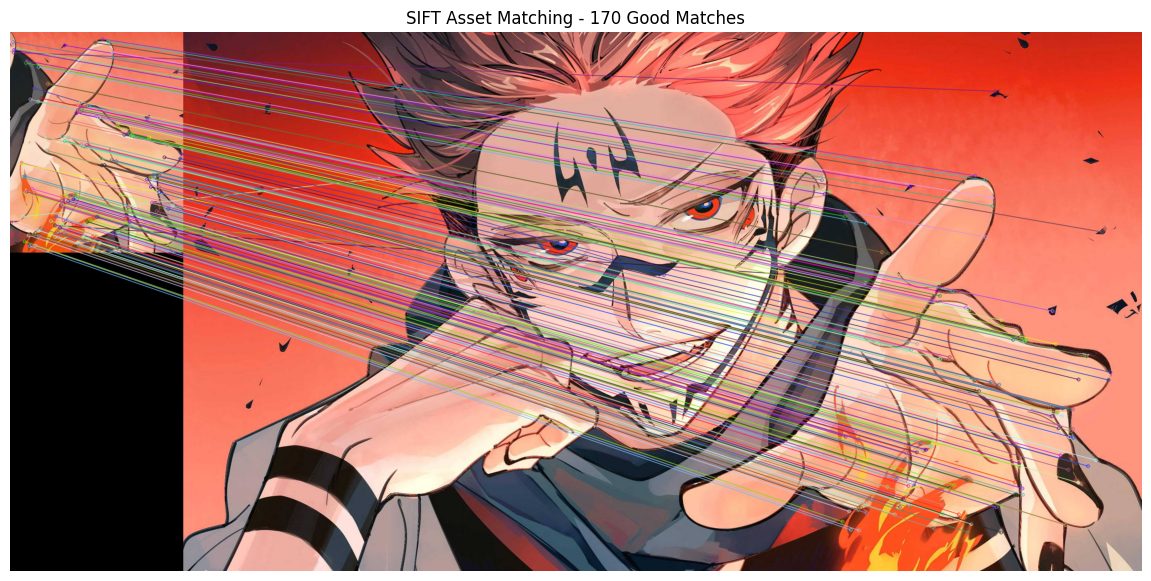

In [6]:
# TASK #02
# ============================================================
# TASK 2
# ASSET TRACKING USING SIFT
# ============================================================
#
# PURPOSE OF THIS TASK:
#
# Is task mein hum SIFT (Scale-Invariant Feature Transform)
# use karke reference image ke important features ko
# test image mein find/match karenge.
#
# Basic flow:
#
# Reference Image + Test Image
#             ↓
#        Convert to Grayscale
#             ↓
#          SIFT Detection
#             ↓
#   Keypoints + Descriptors
#             ↓
#       BFMatcher Matching
#             ↓
#      KNN Matching (k=2)
#             ↓
#       Lowe Ratio Test
#             ↓
#       Good/Reliable Matches
#             ↓
#       Draw Matches Visually
#
# FINAL OUTPUT:
#
# Do images side-by-side show hongi.
# Reference image left side par aur test image right side par.
#
# Dono images ke corresponding SIFT features ke darmiyan
# lines draw hongi.
#
# Har line ka matlab:
# "Reference image ka ye feature test image ke is feature
# se match hua."
#
# Title mein total number of GOOD matches bhi show honge.
# ============================================================


# ------------------------------------------------------------
# IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

# cv2:
# OpenCV library.
# Image reading, grayscale conversion, SIFT, feature matching,
# aur match visualization ke liye use hoti hai.
#
# np:
# NumPy library.
# Is task mein directly bohat zyada use nahi ho rahi,
# lekin image processing tasks mein numerical operations ke
# liye commonly required hoti hai.
#
# plt:
# Matplotlib.
# Final matched image ko display karne ke liye use hoti hai.


# ------------------------------------------------------------
# STEP 1: REFERENCE IMAGE
# ------------------------------------------------------------

reference = cv2.imread("reference.png")

# cv2.imread():
# Image ko computer se read/load karta hai.
#
# Parameter:
# "reference.jpg"
#     ↓
# Image file ka path/name.
#
# Important:
# Agar image current Python/Jupyter folder mein hai,
# sirf "reference.jpg" likhna enough hai.
#
# OpenCV image ko normally BGR format mein read karta hai:
#
# B = Blue
# G = Green
# R = Red
#
# Agar image successfully load ho jaye:
#
# reference → image data (NumPy array)
#
# Agar image nahi mile:
#
# reference = None


# ------------------------------------------------------------
# STEP 2: TEST IMAGE
# ------------------------------------------------------------

test = cv2.imread("sukuna.jpg")

# Ye bhi same tarah image read karta hai.
#
# test image wo image hai jisme hum reference image ke
# features ko find/match karna chahte hain.
#
# Example:
#
# reference.jpg → original/reference asset
# test.jpg      → image jisme asset present ho sakta hai
#
# Agar test.jpg nahi mile:
#
# test = None


# ------------------------------------------------------------
# CHECK WHETHER IMAGES WERE LOADED
# ------------------------------------------------------------

if reference is None or test is None:

    print("One or both images were not found!")

# reference is None:
#     Reference image load nahi hui.
#
# OR
#
# test is None:
#     Test image load nahi hui.
#
# Agar dono mein se koi bhi image missing ho,
# to SIFT processing continue nahi karni chahiye.


else:

    # ========================================================
    # STEP 3: CONVERT IMAGES TO GRAYSCALE
    # ========================================================

    reference_gray = cv2.cvtColor(
        reference,
        cv2.COLOR_BGR2GRAY
    )

    # cv2.cvtColor():
    # Ek color space ko doosre color space mein convert karta hai.
    #
    # Parameters:
    #
    # reference
    #     → jis image ko convert karna hai.
    #
    # cv2.COLOR_BGR2GRAY
    #     → BGR image ko grayscale mein convert karta hai.
    #
    # Color image:
    #
    #     Blue + Green + Red channels
    #
    # Grayscale image:
    #
    #     Sirf intensity/brightness values.
    #
    # SIFT ko grayscale image dena common approach hai,
    # kyunki SIFT features image ki intensity/structure
    # se detect karta hai.


    test_gray = cv2.cvtColor(
        test,
        cv2.COLOR_BGR2GRAY
    )

    # Test image ko bhi BGR se grayscale mein convert kar rahe hain.
    #
    # Ab hamare paas:
    #
    # reference_gray → reference image ka grayscale version
    # test_gray      → test image ka grayscale version


    # ========================================================
    # STEP 4: CREATE SIFT DETECTOR
    # ========================================================

    sift = cv2.SIFT_create()

    # cv2.SIFT_create():
    #
    # SIFT detector + descriptor extractor ka object banata hai.
    #
    # SIFT ka full form:
    #
    # Scale-Invariant Feature Transform
    #
    # SIFT ka kaam:
    #
    # 1. Image mein important/unique points find karna.
    # 2. In points ke around features ko describe karna.
    #
    # Important points ko:
    #
    # KEYPOINTS
    #
    # kehte hain.
    #
    # Har keypoint ke liye SIFT ek numerical description banata hai
    # jise:
    #
    # DESCRIPTOR
    #
    # kehte hain.
    #
    # SIFT ki useful property:
    #
    # Ye scale aur rotation changes ke against relatively
    # robust hota hai.
    #
    # Example:
    #
    # Agar same object test image mein thora:
    #
    # - bada/chhota ho
    # - rotate ho
    #
    # to SIFT uske features ko match karne mein help kar sakta hai.


    # ========================================================
    # STEP 5: DETECT KEYPOINTS + DESCRIPTORS
    # ========================================================

    kp1, des1 = sift.detectAndCompute(
        reference_gray,
        None
    )

    # detectAndCompute():
    #
    # Ye ek hi function se:
    #
    # 1. Keypoints detect karta hai.
    # 2. Un keypoints ke descriptors calculate karta hai.
    #
    # Parameters:
    #
    # reference_gray
    #     → jis image mein features detect karne hain.
    #
    # None
    #     → mask.
    #
    # Mask ka purpose:
    # Agar hum image ke sirf kisi specific area mein
    # features detect karna chahte hon to mask de sakte hain.
    #
    # None ka matlab:
    # Puri image mein features detect karo.
    #
    #
    # OUTPUT:
    #
    # kp1:
    #     Reference image ke KEYPOINTS.
    #
    # des1:
    #     Reference image ke DESCRIPTORS.
    #
    #
    # KEYPOINT kya hai?
    #
    # Image ka important/interesting point.
    #
    # Example:
    #
    #     corners
    #     edges
    #     texture-rich areas
    #     unique patterns
    #
    #
    # DESCRIPTOR kya hai?
    #
    # Har keypoint ki numerical representation.
    #
    # Ye descriptor later test image ke descriptors ke
    # saath compare hota hai.


    kp2, des2 = sift.detectAndCompute(
        test_gray,
        None
    )

    # Same process test image ke liye.
    #
    # kp2:
    #     Test image ke keypoints.
    #
    # des2:
    #     Test image ke descriptors.
    #
    #
    # Ab hamare paas:
    #
    # Reference:
    #     kp1 + des1
    #
    # Test:
    #     kp2 + des2


    # ========================================================
    # STEP 6: CREATE BF MATCHER
    # ========================================================

    bf = cv2.BFMatcher(
        cv2.NORM_L2,
        crossCheck=False
    )

    # BFMatcher:
    # BF ka matlab:
    #
    # Brute Force Matcher
    #
    # Iska kaam:
    #
    # Reference image ke descriptors ko
    # test image ke descriptors ke saath compare karna.
    #
    #
    # FIRST PARAMETER:
    #
    # cv2.NORM_L2
    #
    # Ye distance measurement method hai.
    #
    # SIFT descriptors numerical floating-point vectors hote hain,
    # isliye normally L2 (Euclidean) distance use ki jati hai.
    #
    # Smaller distance:
    #     More similar descriptors
    #
    # Larger distance:
    #     Less similar descriptors
    #
    #
    # Example:
    #
    # Match A → distance = 20
    # Match B → distance = 80
    #
    # A zyada similar hai kyunki uski distance chhoti hai.
    #
    #
    # SECOND PARAMETER:
    #
    # crossCheck=False
    #
    # crossCheck ka purpose:
    # Matching ko dono directions mein verify karna.
    #
    # False ka matlab:
    # Is stage par cross-checking nahi kar rahe.
    #
    # Hum instead KNN matching + Lowe Ratio Test use karenge.
    #
    # Isliye crossCheck=False rakha gaya hai.


    # ========================================================
    # STEP 7: KNN MATCHING
    # ========================================================

    matches = bf.knnMatch(
        des1,
        des2,
        k=2
    )

    # knnMatch():
    #
    # KNN = K-Nearest Neighbors
    #
    # Is function ka kaam:
    #
    # Har reference descriptor ke liye
    # test image mein nearest descriptors find karna.
    #
    #
    # PARAMETERS:
    #
    # des1
    #     → Reference image ke descriptors.
    #
    # des2
    #     → Test image ke descriptors.
    #
    # k=2
    #     → Har descriptor ke liye 2 nearest matches
    #       find karo.
    #
    #
    # k=2 BOHAT IMPORTANT HAI.
    #
    # Humein sirf BEST match nahi chahiye.
    #
    # Humein:
    #
    #     1. Best match
    #     2. Second-best match
    #
    # dono chahiye.
    #
    # Kyunki next step mein Lowe Ratio Test in dono
    # ko compare karega.
    #
    #
    # OUTPUT STRUCTURE:
    #
    # matches ke andar bohat saare pairs honge:
    #
    # matches
    #    |
    #    |--- pair 1 → [m1, n1]
    #    |--- pair 2 → [m2, n2]
    #    |--- pair 3 → [m3, n3]
    #    |--- ...
    #
    # Har pair mein:
    #
    # m = BEST/closest match
    # n = SECOND-BEST/second closest match


    # ========================================================
    # STEP 8: LOWE RATIO TEST
    # ========================================================

    good_matches = []

    # Empty list create kar rahe hain.
    #
    # Is list mein sirf wo matches store honge
    # jo Lowe Ratio Test pass karenge.
    #
    # Initially:
    #
    # good_matches = []
    #
    # Later, for example:
    #
    # good_matches = [match1, match2, match3, ...]


    for pair in matches:

        # matches ke andar har pair ko one-by-one process karenge.
        #
        # Example:
        #
        # pair = [m1, n1]
        # pair = [m2, n2]
        # pair = [m3, n3]
        #
        # etc.


        m, n = pair

        # Har pair mein 2 DMatch objects hote hain.
        #
        # m = BEST MATCH
        # n = SECOND-BEST MATCH
        #
        # DMatch object ke andar matching information hoti hai.
        #
        # Important property:
        #
        # m.distance
        #
        # Match ki distance/similarity measure.
        #
        # Distance SMALL:
        #     Descriptors zyada similar.
        #
        # Distance LARGE:
        #     Descriptors kam similar.


        # ----------------------------------------------------
        # LOWE RATIO TEST CONDITION
        # ----------------------------------------------------
        #
        # Condition:
        #
        # best distance < 0.75 × second-best distance
        #
        # Agar best match second-best match se
        # CLEARLY better hai, to match reliable consider
        # kiya jayega.
        #
        #
        # EXAMPLE OF GOOD MATCH:
        #
        # m.distance = 20
        # n.distance = 80
        #
        # Check:
        #
        # 20 < 0.75 × 80
        # 20 < 60
        #
        # TRUE
        #
        # → Good match
        #
        #
        # EXAMPLE OF BAD/AMBIGUOUS MATCH:
        #
        # m.distance = 60
        # n.distance = 70
        #
        # Check:
        #
        # 60 < 0.75 × 70
        # 60 < 52.5
        #
        # FALSE
        #
        # → Reject
        #
        #
        # WHY?
        #
        # Agar best aur second-best match ki distances
        # almost same hain, to humein confidence nahi hota
        # ke best match actually correct match hai.
        #
        # Isliye ambiguous matches remove kar dete hain.
        #
        #
        # WHY 0.75?
        #
        # 0.75 ek commonly used ratio threshold hai.
        #
        # Lower value:
        #     More strict
        #     Fewer matches
        #     Usually more reliable
        #
        # Higher value:
        #     Less strict
        #     More matches
        #     False matches ka chance zyada
        #
        # Example:
        #
        # 0.6 → very strict
        # 0.7 → strict
        # 0.75 → commonly used
        # 0.8 → less strict
        # 0.9 → very loose


        if m.distance < 0.75 * n.distance:

            # Agar condition TRUE hai:
            #
            # Best match clearly second-best match se
            # better hai.
            #
            # Isliye is match ko reliable/good match
            # consider karenge.


            good_matches.append(m)

            # Sirf BEST MATCH (m) ko save kar rahe hain.
            #
            # n = second-best match hai,
            # isliye usko save nahi karna.
            #
            # Ab good_matches mein sirf reliable matches hain.


    # ========================================================
    # STEP 9: DISPLAY MATCHES
    # ========================================================

    matched_image = cv2.drawMatches(
        reference,
        kp1,
        test,
        kp2,
        good_matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # cv2.drawMatches():
    #
    # Reference aur test image ko side-by-side arrange karta hai
    # aur corresponding matched keypoints ke darmiyan
    # lines draw karta hai.
    #
    #
    # PARAMETERS:
    #
    # --------------------------------------------------------
    # 1. reference
    # --------------------------------------------------------
    #
    # First image.
    #
    # Ye final output mein LEFT side par appear hogi.
    #
    #
    # --------------------------------------------------------
    # 2. kp1
    # --------------------------------------------------------
    #
    # First/reference image ke keypoints.
    #
    # In keypoints ki locations use karke matching lines
    # draw ki jati hain.
    #
    #
    # --------------------------------------------------------
    # 3. test
    # --------------------------------------------------------
    #
    # Second/test image.
    #
    # Ye final output mein RIGHT side par appear hogi.
    #
    #
    # --------------------------------------------------------
    # 4. kp2
    # --------------------------------------------------------
    #
    # Test image ke keypoints.
    #
    # Matching lines yahan ke corresponding points tak
    # draw hongi.
    #
    #
    # --------------------------------------------------------
    # 5. good_matches
    # --------------------------------------------------------
    #
    # Lowe Ratio Test pass karne wale reliable matches.
    #
    # Sirf inhi matches ko visualize kiya jayega.
    #
    #
    # --------------------------------------------------------
    # 6. None
    # --------------------------------------------------------
    #
    # outImg parameter.
    #
    # None ka matlab:
    # Hum output image khud provide nahi kar rahe.
    #
    # OpenCV khud new output image create karega.
    #
    #
    # --------------------------------------------------------
    # 7. flags
    # --------------------------------------------------------
    #
    # Drawing behavior control karta hai.
    #
    # cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    #
    # ka matlab:
    #
    # Unmatched/single keypoints ko draw mat karo.
    #
    # Sirf relevant matched features ko visually show karo.
    #
    # Isse output cleaner aur easier to understand hota hai.
    #
    #
    # FINAL VISUAL:
    #
    #      REFERENCE IMAGE       TEST IMAGE
    #     ┌──────────────┐      ┌──────────────┐
    #     │              │      │              │
    #     │      ●───────┼──────┼───────●      │
    #     │              │      │              │
    #     │    ●─────────┼──────┼─────────●    │
    #     │              │      │              │
    #     │       ●──────┼──────┼──────●       │
    #     │              │      │              │
    #     └──────────────┘      └──────────────┘
    #
    # Har line:
    # Reference image ke ek feature aur test image ke
    # corresponding feature ke match ko represent karti hai.


    # ========================================================
    # STEP 10: BGR → RGB
    # ========================================================

    matched_image = cv2.cvtColor(
        matched_image,
        cv2.COLOR_BGR2RGB
    )

    # OpenCV images normally BGR format mein hoti hain.
    #
    # Matplotlib RGB format expect karta hai.
    #
    # Isliye:
    #
    # BGR → RGB
    #
    # conversion kar rahe hain.
    #
    # Agar conversion na karein to displayed image ke
    # colors incorrect/inverted appear ho sakte hain.


    # ========================================================
    # STEP 11: CREATE MATPLOTLIB FIGURE
    # ========================================================

    plt.figure(figsize=(15, 7))

    # plt.figure():
    # Nayi Matplotlib figure create karta hai.
    #
    # figsize=(15, 7):
    #
    # Width  = 15 inches
    # Height = 7 inches
    #
    # Hum do images side-by-side show kar rahe hain,
    # isliye wide figure useful hai.


    # ========================================================
    # STEP 12: DISPLAY MATCHED IMAGE
    # ========================================================

    plt.imshow(matched_image)

    # plt.imshow():
    # Image ko Matplotlib window/output mein display karta hai.


    # ========================================================
    # STEP 13: DISPLAY NUMBER OF GOOD MATCHES
    # ========================================================

    plt.title(
        "SIFT Asset Matching - "
        + str(len(good_matches))
        + " Good Matches"
    )

    # len(good_matches):
    #
    # Lowe Ratio Test pass karne wale matches ki total count.
    #
    # Example:
    #
    # Agar:
    #
    # len(good_matches) = 35
    #
    # to title hoga:
    #
    # SIFT Asset Matching - 35 Good Matches
    #
    #
    # str():
    # Number ko text/string mein convert karta hai.
    #
    # Example:
    #
    # 35 → "35"
    #
    # Taake hum usay text ke saath concatenate kar saken.


    # ========================================================
    # STEP 14: HIDE AXES
    # ========================================================

    plt.axis("off")

    # Image visualization mein x-axis aur y-axis ki
    # normally zaroorat nahi hoti.
    #
    # "off":
    #
    # Axes, numbers aur ticks hide kar deta hai.
    #
    # Isse final output clean nazar aata hai.


    # ========================================================
    # STEP 15: SHOW FINAL RESULT
    # ========================================================

    plt.show()

    # Final figure ko screen par display karta hai.


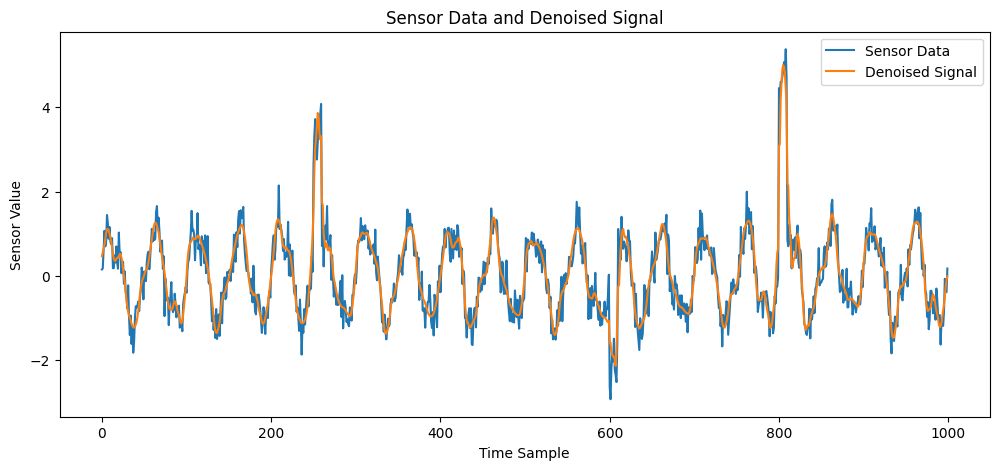

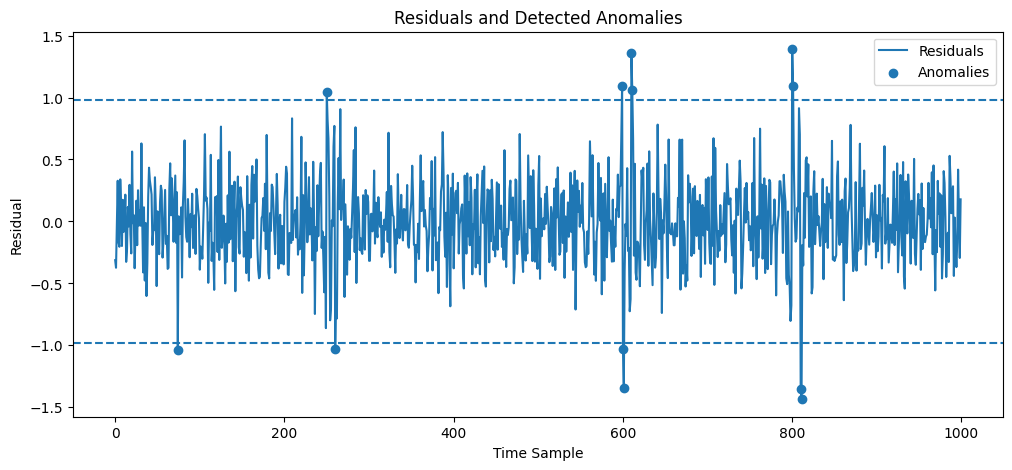

In [7]:
# TASK 03
# ============================================================
# TASK 3
# SENSOR ANOMALY DETECTION USING WAVELET TRANSFORM
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pywt


# ------------------------------------------------------------
# STEP 1: CREATE SAMPLE SENSOR DATA
# ------------------------------------------------------------

# Reproducible random numbers ke liye.
np.random.seed(42)

# 1000 time samples.
t = np.linspace(0, 10, 1000)

# Normal sensor signal.
signal = (
    np.sin(2 * np.pi * 2 * t)
    + 0.3 * np.sin(2 * np.pi * 5 * t)
)

# Random noise.
noise = 0.3 * np.random.randn(1000)

# Actual observed sensor data.
sensor_data = signal + noise


# ------------------------------------------------------------
# STEP 2: ADD SOME ARTIFICIAL ANOMALIES
# ------------------------------------------------------------

# Anomaly means unusual/abnormal sensor behavior.

sensor_data[250:260] += 3
sensor_data[600:610] -= 3
sensor_data[800:810] += 4


# ------------------------------------------------------------
# STEP 3: WAVELET DECOMPOSITION
# ------------------------------------------------------------

# 'db4' = Daubechies wavelet family, order 4.
#
# wavedec():
# Signal ko multiple levels par decompose karta hai.
#
# level=3:
# 3 levels ki decomposition.
coefficients = pywt.wavedec(
    sensor_data,
    "db4",
    level=3
)


# ------------------------------------------------------------
# STEP 4: THRESHOLDING
# ------------------------------------------------------------

# Wavelet coefficients mein noise usually
# small values ki form mein hota hai.
#
# Threshold calculate karne ke liye MAD use kar rahe hain.

detail_coefficients = coefficients[-1]

sigma = (
    np.median(
        np.abs(detail_coefficients)
    ) / 0.6745
)

threshold = (
    sigma
    * np.sqrt(
        2 * np.log(len(sensor_data))
    )
)


# ------------------------------------------------------------
# STEP 5: REMOVE SMALL COEFFICIENTS
# ------------------------------------------------------------

denoised_coefficients = []

for i, coeff in enumerate(coefficients):

    # Approximation coefficient ko unchanged rakhte hain.
    if i == 0:

        denoised_coefficients.append(coeff)

    else:

        # Soft threshold:
        # Small/noisy values ko zero ke paas shrink karta hai.
        filtered = pywt.threshold(
            coeff,
            threshold,
            mode="soft"
        )

        denoised_coefficients.append(
            filtered
        )


# ------------------------------------------------------------
# STEP 6: RECONSTRUCT DENOISED SIGNAL
# ------------------------------------------------------------

denoised_signal = pywt.waverec(
    denoised_coefficients,
    "db4"
)

# Reconstruction ki length kabhi original se
# 1-2 samples different ho sakti hai.
denoised_signal = denoised_signal[:len(sensor_data)]


# ------------------------------------------------------------
# STEP 7: CALCULATE RESIDUAL
# ------------------------------------------------------------

# Residual = observed signal - denoised signal
#
# Agar residual bohat large ho:
# possible anomaly.
residual = sensor_data - denoised_signal


# ------------------------------------------------------------
# STEP 8: ANOMALY THRESHOLD
# ------------------------------------------------------------

# Residual ki standard deviation.
residual_std = np.std(residual)

# 3 sigma rule.
anomaly_threshold = 3 * residual_std

# Boolean array:
# True = anomaly
# False = normal
anomalies = np.abs(residual) > anomaly_threshold


# ------------------------------------------------------------
# STEP 9: DISPLAY SENSOR DATA + DENOISED SIGNAL
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    sensor_data,
    label="Sensor Data"
)

plt.plot(
    denoised_signal,
    label="Denoised Signal"
)

plt.title("Sensor Data and Denoised Signal")
plt.xlabel("Time Sample")
plt.ylabel("Sensor Value")
plt.legend()
plt.show()


# ------------------------------------------------------------
# STEP 10: DISPLAY RESIDUALS + ANOMALIES
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    residual,
    label="Residuals"
)

plt.scatter(
    np.where(anomalies)[0],
    residual[anomalies],
    label="Anomalies"
)

plt.axhline(
    anomaly_threshold,
    linestyle="--"
)

plt.axhline(
    -anomaly_threshold,
    linestyle="--"
)

plt.title("Residuals and Detected Anomalies")
plt.xlabel("Time Sample")
plt.ylabel("Residual")
plt.legend()
plt.show()

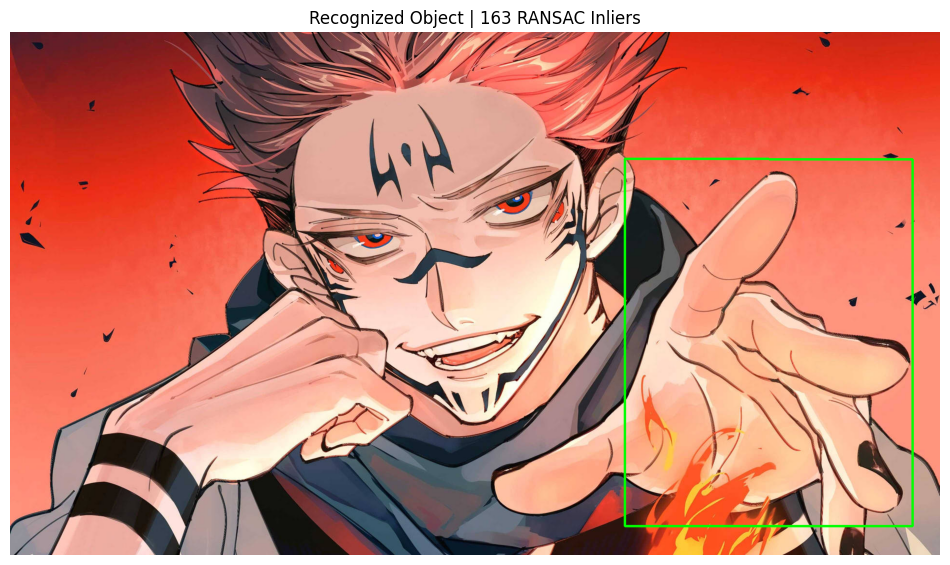

In [9]:

# ============================================================
# TASK 4
# OBJECT RECOGNITION USING SIFT
# ============================================================
#
# OBJECTIVE:
# Reference image mein maujood object ko test image mein
# recognize karna aur uski estimated location par green
# bounding box draw karna.
#
# COMPLETE PIPELINE:
#
# Reference Image + Test Image
#              |
#              v
#       Grayscale Conversion
#              |
#              v
#      SIFT Keypoints + Descriptors
#              |
#              v
#        BFMatcher + KNN
#              |
#              v
#        Lowe Ratio Test
#              |
#              v
#     Corresponding Point Pairs
#              |
#              v
#       Homography using RANSAC
#              |
#              v
#       Transform Image Corners
#              |
#              v
#      Draw Green Bounding Box
#              |
#              v
#         Display Result
#
# IMPORTANT:
# Homography-based recognition works best when the object
# is approximately planar, enough correct matches exist,
# and the matches are distributed across the object.
# ============================================================


# ------------------------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

# cv2:
# OpenCV library. Image processing, SIFT, matching,
# homography aur drawing ke liye use hoti hai.
#
# numpy:
# Numerical arrays aur coordinate points handle karne ke liye.
#
# matplotlib.pyplot:
# Final output image display karne ke liye.


# ============================================================
# STEP 1: READ IMAGES
# ============================================================

reference = cv2.imread("reference.png")
test = cv2.imread("sukuna.jpg")

# cv2.imread(path):
# Image file ko read karke NumPy array return karta hai.
#
# Parameter:
# path = image ka filename ya file path.
#
# reference:
# Original object ki image, jise recognize karna hai.
#
# test:
# Wo image jisme reference object ko find karna hai.
#
# OpenCV normally images ko BGR format mein read karta hai.
#
# Agar image successfully load na ho:
# cv2.imread() None return karta hai.


# Check whether both images were loaded successfully.

if reference is None or test is None:

    print("Image not found! Check the image filenames and paths.")

else:

    # ========================================================
    # STEP 2: CONVERT IMAGES TO GRAYSCALE
    # ========================================================

    gray_reference = cv2.cvtColor(
        reference,
        cv2.COLOR_BGR2GRAY
    )

    gray_test = cv2.cvtColor(
        test,
        cv2.COLOR_BGR2GRAY
    )

    # cv2.cvtColor(src, code):
    #
    # src:
    #     Input image.
    #
    # code:
    #     Kis type ki color conversion karni hai.
    #
    # cv2.COLOR_BGR2GRAY:
    #     BGR color image ko grayscale mein convert karta hai.
    #
    # Grayscale image mein brightness/intensity values hoti hain.
    # SIFT ke liye grayscale input use karna common hai.
    #
    # Output:
    # gray_reference = reference ki grayscale image
    # gray_test      = test ki grayscale image


    # ========================================================
    # STEP 3: CREATE SIFT DETECTOR
    # ========================================================

    sift = cv2.SIFT_create()

    # SIFT = Scale-Invariant Feature Transform.
    #
    # SIFT image mein distinctive/important points detect karta
    # hai aur har point ka numerical descriptor banata hai.
    #
    # Keypoints:
    #     Image ke important feature points aur unki locations.
    #
    # Descriptors:
    #     Har keypoint ki numerical feature representation.
    #
    # SIFT scale aur rotation changes ke against relatively
    # robust features provide karta hai.
    #
    # cv2.SIFT_create() default settings use kar raha hai.
    # Is function mein optional parameters bhi diye ja sakte
    # hain, jaise nfeatures, contrastThreshold aur sigma.


    # ========================================================
    # STEP 4: FIND KEYPOINTS AND DESCRIPTORS
    # ========================================================

    kp1, des1 = sift.detectAndCompute(
        gray_reference,
        None
    )

    # detectAndCompute(image, mask):
    #
    # image:
    #     Grayscale image jisme features find karne hain.
    #
    # mask:
    #     Optional region mask.
    #     None ka matlab poori image process karo.
    #
    # kp1:
    #     Reference image ke keypoints.
    #
    # des1:
    #     Reference image ke keypoints ke descriptors.
    #
    # Har SIFT descriptor normally 128 numerical values
    # par mushtamil hota hai.


    kp2, des2 = sift.detectAndCompute(
        gray_test,
        None
    )

    # Test image par bhi same process apply hota hai.
    #
    # kp2:
    #     Test image ke keypoints.
    #
    # des2:
    #     Test image ke descriptors.
    #
    # Ab reference aur test image ke features compare kiye
    # ja sakte hain.


    # --------------------------------------------------------
    # CHECK WHETHER DESCRIPTORS EXIST
    # --------------------------------------------------------

    if des1 is None or des2 is None:

        print("Could not find enough features in the images.")

    else:

        # ====================================================
        # STEP 5: MATCH DESCRIPTORS USING BF MATCHER
        # ====================================================

        matcher = cv2.BFMatcher(
            cv2.NORM_L2
        )

        # BFMatcher = Brute Force Matcher.
        #
        # Ye reference descriptors ko test descriptors ke
        # saath compare karke nearest matches find karta hai.
        #
        # Parameter:
        #
        # cv2.NORM_L2:
        #     Euclidean distance use karta hai.
        #
        # SIFT descriptors ke liye NORM_L2 common choice hai.
        #
        # Smaller distance:
        #     Descriptors zyada similar.
        #
        # Larger distance:
        #     Descriptors kam similar.
        #
        # BFMatcher ka crossCheck default False hai.
        # Yahan hum KNN matching aur Lowe Ratio Test use karenge.


        # ====================================================
        # STEP 6: K-NEAREST NEIGHBOR MATCHING
        # ====================================================

        matches = matcher.knnMatch(
            des1,
            des2,
            k=2
        )

        # knnMatch(queryDescriptors, trainDescriptors, k):
        #
        # des1:
        #     Reference image ke descriptors.
        #
        # des2:
        #     Test image ke descriptors.
        #
        # k=2:
        #     Har reference descriptor ke 2 nearest matches
        #     find karo.
        #
        # Har pair mein:
        #
        # m = best/closest match
        # n = second-best/second closest match
        #
        # In dono matches ko next step mein compare karenge.


        # ====================================================
        # STEP 7: LOWE RATIO TEST
        # ====================================================

        good_matches = []

        # Empty list banayi hai.
        # Ismein sirf Lowe Ratio Test pass karne wale matches
        # store honge.

        for pair in matches:

            # KNN normally har pair mein 2 matches deta hai.
            #
            # Lekin kuch situations mein pair mein 2 matches
            # available nahi hote, isliye length check karte hain.

            if len(pair) < 2:
                continue

            m, n = pair

            # m = best match
            # n = second-best match
            #
            # m.distance aur n.distance un matches ki
            # descriptor distances hain.
            #
            # Lowe Ratio Test:
            #
            # best distance < 0.75 * second-best distance
            #
            # Example:
            #
            # m.distance = 20
            # n.distance = 80
            #
            # 20 < 0.75 * 80
            # 20 < 60  -> True
            #
            # Isliye m ko good match samjha jayega.
            #
            # Agar dono distances almost same hon, to match
            # ambiguous ho sakta hai aur reject ho jayega.
            #
            # 0.75 ek commonly used threshold hai.
            # Lower threshold zyada strict hota hai;
            # higher threshold zyada matches allow karta hai.

            if m.distance < 0.75 * n.distance:

                good_matches.append(m)

                # Sirf best match m ko store karte hain,
                # second-best match n ko nahi.


        # ====================================================
        # STEP 8: CHECK NUMBER OF GOOD MATCHES
        # ====================================================

        # Homography calculate karne ke liye kam az kam
        # 4 suitable point correspondences chahiye.
        #
        # Sirf 4 matches hona accuracy ki guarantee nahi hai.
        # Matches geometrically consistent bhi hone chahiye.

        if len(good_matches) < 4:

            print(
                "Not enough good matches "
                "to calculate homography."
            )

        else:

            # ================================================
            # STEP 9: EXTRACT MATCHING COORDINATES
            # ================================================

            src_points = np.float32([
                kp1[m.queryIdx].pt
                for m in good_matches
            ]).reshape(-1, 1, 2)

            # Reference image ke matched keypoint coordinates.
            #
            # m.queryIdx:
            #     Reference descriptors mein matched keypoint
            #     ka index.
            #
            # kp1[m.queryIdx]:
            #     Reference image ka corresponding KeyPoint.
            #
            # .pt:
            #     Keypoint ki (x, y) coordinate.
            #
            # np.float32():
            #     Coordinates ko 32-bit floating-point values
            #     mein convert karta hai.
            #
            # reshape(-1, 1, 2):
            #     Coordinates ko OpenCV ke required format mein
            #     arrange karta hai.
            #
            # -1:
            #     Number of points automatically calculate karo.
            #
            # 1:
            #     Har point ke liye ek row/group.
            #
            # 2:
            #     Har point ke do coordinates: x and y.
            #
            # Example shape:
            # (number_of_matches, 1, 2)


            dst_points = np.float32([
                kp2[m.trainIdx].pt
                for m in good_matches
            ]).reshape(-1, 1, 2)

            # Test image ke corresponding matched coordinates.
            #
            # m.trainIdx:
            #     Test descriptors mein matched keypoint ka index.
            #
            # kp2[m.trainIdx].pt:
            #     Test image mein us keypoint ki (x, y) location.
            #
            # IMPORTANT:
            #
            # src_points = reference image ke points
            # dst_points = test image ke corresponding points
            #
            # Dono lists ka order same rehna chahiye,
            # taake har source point ka correct destination point
            # ke saath correspondence ho.


            # ================================================
            # STEP 10: CALCULATE HOMOGRAPHY USING RANSAC
            # ================================================

            H, mask = cv2.findHomography(
                src_points,
                dst_points,
                cv2.RANSAC,
                5.0
            )

            # cv2.findHomography(srcPoints, dstPoints,
            #                    method, ransacReprojThreshold)
            #
            # src_points:
            #     Reference image ke matched points.
            #
            # dst_points:
            #     Test image ke corresponding points.
            #
            # cv2.RANSAC:
            #     Random Sample Consensus method.
            #     Incorrect/outlier matches ke effect ko reduce
            #     karke suitable homography estimate karta hai.
            #
            # 5.0:
            #     Reprojection-error threshold, pixels mein.
            #
            # RANSAC is threshold ko use karke decide karta hai
            # ke estimated transformation ke liye koi match
            # inlier hai ya outlier.
            #
            # Smaller threshold:
            #     More strict geometric agreement.
            #
            # Larger threshold:
            #     More points accept ho sakte hain, lekin
            #     incorrect points accept hone ka risk bhi hai.
            #
            # OUTPUT:
            #
            # H:
            #     3x3 homography matrix.
            #
            # mask:
            #     Inlier/outlier information.
            #     Usually 1 = inlier, 0 = outlier.
            #
            # Homography reference image ke points ko test
            # image ki coordinates mein map karti hai.


            # ------------------------------------------------
            # CHECK WHETHER HOMOGRAPHY WAS FOUND
            # ------------------------------------------------

            if H is None or mask is None:

                print("Homography could not be calculated.")

            else:

                # ============================================
                # STEP 11: CHECK RANSAC INLIERS
                # ============================================

                inlier_count = int(mask.sum())

                # mask.sum():
                # RANSAC ke inliers ki count nikalta hai,
                # kyunki inliers normally 1 aur outliers 0 hote hain.
                #
                # int():
                # Count ko normal integer mein convert karta hai.
                #
                # Zyada geometrically consistent matches
                # homography ke liye useful evidence dete hain.
                #
                # Lekin sirf inlier count se recognition ki
                # correctness guarantee nahi hoti.

                if inlier_count < 4:

                    print(
                        "Not enough RANSAC inliers "
                        "for reliable corner transformation."
                    )

                else:

                    # ========================================
                    # STEP 12: GET REFERENCE IMAGE CORNERS
                    # ========================================

                    h, w = gray_reference.shape

                    # Grayscale image ka shape:
                    # (height, width)
                    #
                    # h = reference image ki height
                    # w = reference image ki width
                    #
                    # In dimensions se four corners define honge.


                    corners = np.float32([
                        [0, 0],       # Top-left
                        [w, 0],       # Top-right
                        [w, h],       # Bottom-right
                        [0, h]        # Bottom-left
                    ]).reshape(-1, 1, 2)

                    # Ye reference image ke four boundary corners hain.
                    #
                    # [0, 0] = top-left
                    # [w, 0] = top-right
                    # [w, h] = bottom-right
                    # [0, h] = bottom-left
                    #
                    # np.float32():
                    # Coordinates ko floating-point format mein
                    # convert karta hai.
                    #
                    # reshape(-1, 1, 2):
                    # OpenCV ke required point format mein arrange
                    # karta hai.


                    # ========================================
                    # STEP 13: TRANSFORM CORNERS
                    # ========================================

                    transformed_corners = cv2.perspectiveTransform(
                        corners,
                        H
                    )

                    # cv2.perspectiveTransform(src, m):
                    #
                    # corners:
                    #     Original reference image ke four corners.
                    #
                    # H:
                    #     Estimated 3x3 homography matrix.
                    #
                    # Ye function corners ki estimated locations
                    # test image mein calculate karta hai.
                    #
                    # Result:
                    # transformed_corners
                    #
                    # Ab in transformed corners ko connect karke
                    # test image par object ki estimated boundary
                    # draw kar sakte hain.


                    # ========================================
                    # STEP 14: DRAW BOUNDING BOX
                    # ========================================

                    test_with_box = test.copy()

                    # copy():
                    # Original test image ki separate copy banata hai.
                    #
                    # Isse original test image modify nahi hoti.
                    # Drawing sirf test_with_box par hogi.


                    cv2.polylines(
                        test_with_box,
                        [np.int32(transformed_corners)],
                        True,
                        (0, 255, 0),
                        3
                    )

                    # cv2.polylines(img, pts, isClosed, color, thickness)
                    #
                    # test_with_box:
                    #     Wo image jis par box draw karna hai.
                    #
                    # [np.int32(transformed_corners)]:
                    #     Transformed corner coordinates.
                    #
                    # np.int32():
                    #     Coordinates ko integer values mein convert
                    #     karta hai, jo drawing ke liye use hongi.
                    #
                    # Outer []:
                    #     Polygon points ko polygons ki list mein
                    #     pass karne ke liye.
                    #
                    # True:
                    #     Polygon close karo; last corner ko first
                    #     corner se connect karo.
                    #
                    # False karne par last side draw nahi hoti.
                    #
                    # (0, 255, 0):
                    #     BGR format mein GREEN color.
                    #
                    # (255, 0, 0) = Blue in BGR
                    # (0, 0, 255) = Red in BGR
                    # (0, 255, 0) = Green in BGR
                    #
                    # 3:
                    #     Boundary line ki thickness in pixels.
                    #
                    # Final result mein object ke around green
                    # quadrilateral/box nazar aayega.


                    # ========================================
                    # STEP 15: CONVERT BGR TO RGB
                    # ========================================

                    result = cv2.cvtColor(
                        test_with_box,
                        cv2.COLOR_BGR2RGB
                    )

                    # OpenCV image format = BGR
                    # Matplotlib display format = RGB
                    #
                    # cv2.COLOR_BGR2RGB:
                    # BGR channels ko RGB order mein convert karta hai.
                    #
                    # Is conversion se display ke colors correct
                    # nazar aate hain.


                    # ========================================
                    # STEP 16: DISPLAY FINAL RESULT
                    # ========================================

                    plt.figure(figsize=(12, 7))

                    # figsize=(12, 7):
                    # Figure width = 12 inches
                    # Figure height = 7 inches
                    #
                    # Ye sirf output display ki size control karta hai.


                    plt.imshow(result)

                    # result image ko display karta hai.
                    # Green bounding box image par already draw ho chuka hai.


                    plt.title(
                        "Recognized Object | "
                        + str(inlier_count)
                        + " RANSAC Inliers"
                    )

                    # str(inlier_count):
                    # Inlier count ko text mein convert karta hai.
                    #
                    # Example:
                    # Recognized Object | 25 RANSAC Inliers
                    #
                    # Note:
                    # Inlier count support information hai;
                    # ye recognition ki guaranteed accuracy score nahi.


                    plt.axis("off")

                    # X-axis, Y-axis, ticks aur numbers hide karta hai.
                    # Isse image clean nazar aati hai.


                    plt.show()

                    # Final image screen/output par display karta hai.

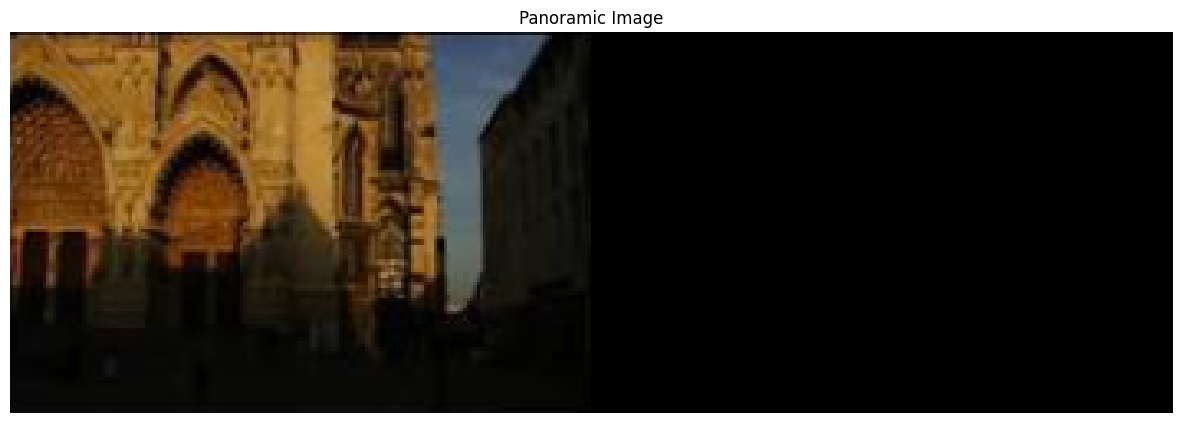

In [10]:
# ============================================================
# TASK 5
# PANORAMIC IMAGE USING SIFT
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# STEP 1: READ TWO OVERLAPPING IMAGES
# ------------------------------------------------------------

image1 = cv2.imread("left.png")
image2 = cv2.imread("right.png")


if image1 is None or image2 is None:

    print("Images not found!")

else:

    # --------------------------------------------------------
    # STEP 2: GRAYSCALE
    # --------------------------------------------------------

    gray1 = cv2.cvtColor(
        image1,
        cv2.COLOR_BGR2GRAY
    )

    gray2 = cv2.cvtColor(
        image2,
        cv2.COLOR_BGR2GRAY
    )


    # --------------------------------------------------------
    # STEP 3: SIFT
    # --------------------------------------------------------

    sift = cv2.SIFT_create()


    # Find keypoints and descriptors.
    kp1, des1 = sift.detectAndCompute(
        gray1,
        None
    )

    kp2, des2 = sift.detectAndCompute(
        gray2,
        None
    )


    # --------------------------------------------------------
    # STEP 4: FEATURE MATCHING
    # --------------------------------------------------------

    matcher = cv2.BFMatcher(
        cv2.NORM_L2
    )

    matches = matcher.knnMatch(
        des1,
        des2,
        k=2
    )


    # --------------------------------------------------------
    # STEP 5: GOOD MATCHES
    # --------------------------------------------------------

    good_matches = []

    for m, n in matches:

        if m.distance < 0.75 * n.distance:

            good_matches.append(m)


    # --------------------------------------------------------
    # STEP 6: HOMOGRAPHY
    # --------------------------------------------------------

    if len(good_matches) >= 4:

        src_points = np.float32([
            kp1[m.queryIdx].pt
            for m in good_matches
        ]).reshape(-1, 1, 2)


        dst_points = np.float32([
            kp2[m.trainIdx].pt
            for m in good_matches
        ]).reshape(-1, 1, 2)


        H, mask = cv2.findHomography(
            src_points,
            dst_points,
            cv2.RANSAC,
            5.0
        )


        # ----------------------------------------------------
        # STEP 7: CREATE LARGE CANVAS
        # ----------------------------------------------------

        h1, w1 = image1.shape[:2]
        h2, w2 = image2.shape[:2]

        panorama_width = w1 + w2
        panorama_height = max(h1, h2)


        # ----------------------------------------------------
        # STEP 8: WARP FIRST IMAGE
        # ----------------------------------------------------

        warped_image1 = cv2.warpPerspective(
            image1,
            H,
            (panorama_width, panorama_height)
        )


        # ----------------------------------------------------
        # STEP 9: PUT SECOND IMAGE ON CANVAS
        # ----------------------------------------------------

        warped_image1[
            0:h2,
            0:w2
        ] = image2


        # ----------------------------------------------------
        # STEP 10: DISPLAY
        # ----------------------------------------------------

        panorama_rgb = cv2.cvtColor(
            warped_image1,
            cv2.COLOR_BGR2RGB
        )

        plt.figure(figsize=(15, 7))
        plt.imshow(panorama_rgb)
        plt.title("Panoramic Image")
        plt.axis("off")
        plt.show()

    else:

        print("Not enough good matches.")

| Line              |                     Slope | `abs(slope)` |
| ----------------- | ------------------------: | -----------: |
| Horizontal        |                       `0` |          `0` |
| Slightly diagonal |                     `0.2` |        `0.2` |
| Diagonal          |                     `0.8` |        `0.8` |
| Steep diagonal    |                       `2` |          `2` |
| Vertical          | undefined / division by 0 |            — |



verical lines check ===>> if(x1==x2)

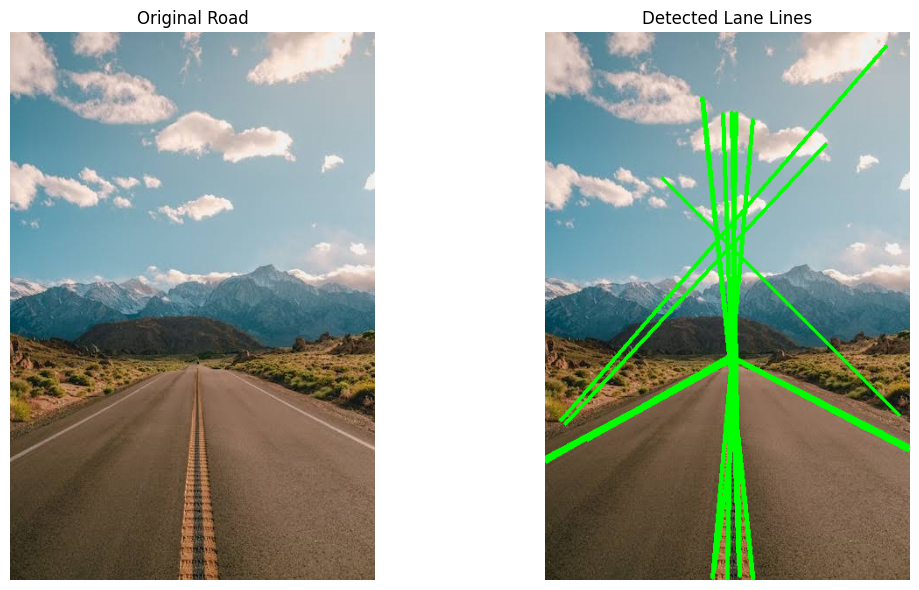

In [11]:

# ============================================================
# TASK 6
# LANE DETECTION USING HOUGH LINE TRANSFORM
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# STEP 1: READ IMAGE
# ------------------------------------------------------------

# cv2.imread() image ko read karta hai.
#
# Parameter:
# "road.jpg" = image ka file name/path.
#
# By default image color/BGR format mein read hoti hai.
#
# Agar image load na ho to cv2.imread() None return karta hai.

image = cv2.imread("lanes.jfif")


# Check kar rahe hain ke image successfully load hui
# ya nahi.

if image is None:

    print("Road image not found!")

else:

    # Original image ki copy bana rahe hain.
    #
    # Hum detected lines "output" par draw karenge
    # taake original image safe rahe.
    output = image.copy()


    # --------------------------------------------------------
    # STEP 2: CONVERT IMAGE TO GRAYSCALE
    # --------------------------------------------------------

    # Canny Edge Detection ke liye grayscale image
    # use karna convenient hota hai.
    #
    # OpenCV images BGR format mein hoti hain:
    # B = Blue
    # G = Green
    # R = Red
    #
    # COLOR_BGR2GRAY:
    # BGR image ko grayscale image mein convert karta hai.

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # --------------------------------------------------------
    # STEP 3: GAUSSIAN BLUR
    # --------------------------------------------------------

    # GaussianBlur image ko smooth karta hai.
    #
    # Iska purpose:
    # Image mein chota unwanted noise reduce karna.
    #
    # Agar noise zyada ho to Canny bohat saari
    # unwanted edges detect kar sakta hai.
    #
    # Parameters:
    #
    # gray = input image
    #
    # (5,5) = Gaussian kernel size
    # 5 x 5 neighborhood use hoga.
    #
    # Common values:
    # (3,3), (5,5), (7,7), etc.
    #
    # Bara kernel → zyada blur
    # Chota kernel → kam blur
    #
    # 0 = sigmaX automatically calculate karne do.

    blur = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )


    # --------------------------------------------------------
    # STEP 4: CANNY EDGE DETECTION
    # --------------------------------------------------------

    # Canny image mein strong intensity changes
    # yani edges detect karta hai.
    #
    # Parameters:
    #
    # blur = input image
    #
    # 50 = lower threshold
    # 150 = upper threshold
    #
    # Lower threshold kam karne se:
    # → zyada edges detect ho sakti hain
    # → unwanted edges bhi aa sakti hain
    #
    # Upper threshold zyada karne se:
    # → sirf stronger edges detect hongi.
    #
    # Example:
    # Canny(blur, 30, 100) → relatively more edges
    # Canny(blur, 50, 150) → current setting
    # Canny(blur, 100, 200) → fewer/stronger edges

    edges = cv2.Canny(
        blur,
        50,
        150
    )


    # --------------------------------------------------------
    # STEP 5: HOUGH LINE TRANSFORM
    # --------------------------------------------------------

    # HoughLinesP Canny se milne wali edges mein
    # straight line segments find karta hai.
    #
    # "P" = Probabilistic Hough Line Transform.
    #
    # Har detected line ka result generally:
    #
    # [x1, y1, x2, y2]
    #
    # hota hai.
    #
    # Matlab:
    # (x1,y1) = line ka starting point
    # (x2,y2) = line ka ending point

    lines = cv2.HoughLinesP(

        edges,

        # ----------------------------------------------------
        # rho = 1
        # ----------------------------------------------------
        # Distance/rho resolution.
        #
        # 1 ka matlab approximately 1-pixel resolution
        # use karna.

        1,

        # ----------------------------------------------------
        # theta = np.pi / 180
        # ----------------------------------------------------
        # Angle resolution.
        #
        # Hough Transform angles radians mein use karta hai.
        #
        # pi radians = 180 degrees
        #
        # Therefore:
        #
        # np.pi / 180 = 1 degree
        #
        # Matlab angle ko approximately 1-degree steps mein
        # consider kiya jayega.

        np.pi / 180,

        # ----------------------------------------------------
        # threshold = 50
        # ----------------------------------------------------
        # Hough accumulator mein minimum number of votes/
        # support required for a line.
        #
        # Higher threshold:
        # → fewer but stronger lines
        #
        # Lower threshold:
        # → more lines
        # → unwanted lines ka chance bhi zyada
        #
        # Current value = 50

        threshold=50,

        # ----------------------------------------------------
        # minLineLength = 50
        # ----------------------------------------------------
        # Minimum line length in pixels.
        #
        # Agar detected line 50 pixels se choti hai
        # to usay ignore kar diya jayega.
        #
        # Higher value:
        # → short lines reject
        #
        # Lower value:
        # → short lines bhi detect hongi.

        minLineLength=50,

        # ----------------------------------------------------
        # maxLineGap = 100
        # ----------------------------------------------------
        # Agar same straight line ke do pieces ke darmiyan
        # gap ho, to maximum 100 pixels ka gap allow hoga.
        #
        # Example:
        #
        # ---------     ---------
        #           gap
        #
        # Agar gap <= 100 pixels ho to pieces ko
        # same line segment ka part consider kiya ja sakta hai.
        #
        # Higher value:
        # → bigger gaps join ho sakte hain.
        #
        # Lower value:
        # → sirf smaller gaps join honge.

        maxLineGap=100
    )


    # --------------------------------------------------------
    # STEP 6: DETECTED LINES KO FILTER AUR DRAW KARNA
    # --------------------------------------------------------

    # Check karte hain ke Hough Transform ne koi lines
    # detect ki hain ya nahi.

    if lines is not None:

        # Har detected line ko one-by-one process karenge.

        for line in lines:

            # HoughLinesP ka output nested form mein hota hai.
            #
            # line[0] se actual four values milti hain:
            #
            # x1, y1 = starting point
            # x2, y2 = ending point

            x1, y1, x2, y2 = line[0]


            # ------------------------------------------------
            # SLOPE CALCULATION
            # ------------------------------------------------

            # Slope ka formula:
            #
            # slope = (y2 - y1) / (x2 - x1)
            #
            # Slope humein batati hai ke line kitni
            # horizontal ya diagonal hai.
            #
            # IMPORTANT:
            #
            # Agar x2 == x1 ho to denominator zero hoga.
            #
            # Is case mein line vertical hai.
            #
            # Isliye pehle check kar rahe hain:
            #
            # x2 != x1
            #
            # Matlab:
            # "Sirf non-vertical lines ki slope calculate karo."

            if x2 != x1:

                slope = (
                    (y2 - y1)
                    / (x2 - x1)
                )


                # ------------------------------------------------
                # SLOPE FILTER
                # ------------------------------------------------

                # abs() negative slope ko positive magnitude
                # mein convert karta hai.
                #
                # Example:
                #
                # abs(-0.8) = 0.8
                # abs(+0.8) = 0.8
                #
                # Isliye left aur right dono directions ki
                # diagonal lane lines ko consider kar sakte hain.
                #
                #
                # CURRENT THRESHOLD = 0.5
                #
                # abs(slope) <= 0.5
                # → line mostly horizontal
                # → reject
                #
                # abs(slope) > 0.5
                # → line sufficiently diagonal
                # → accept
                #
                #
                # Agar 0.5 ko:
                #
                # 0.3 kar dein:
                # → relatively more diagonal + less-steep lines
                #   bhi accept hongi.
                #
                # 1.0 kar dein:
                # → sirf more steep lines accept hongi.
                #
                # 2.0 kar dein:
                # → bohat steep lines hi accept hongi.
                #
                # NOTE:
                # 0.5 koi universal fixed value nahi hai.
                # Image/road ke according adjust ki ja sakti hai.

                if abs(slope) > 0.5:


                    # ------------------------------------------------
                    # DRAW LINE
                    # ------------------------------------------------

                    # cv2.line() selected line ko output image
                    # par draw karta hai.
                    #
                    # Parameters:
                    #
                    # output = jis image par line draw karni hai
                    #
                    # (x1,y1) = starting point
                    #
                    # (x2,y2) = ending point
                    #
                    # (0,255,0) = GREEN in OpenCV BGR format
                    #
                    # 3 = line thickness in pixels

                    cv2.line(
                        output,
                        (x1, y1),
                        (x2, y2),
                        (0, 255, 0),
                        3
                    )


    # --------------------------------------------------------
    # STEP 7: BGR TO RGB
    # --------------------------------------------------------

    # OpenCV BGR format use karta hai.
    # Matplotlib RGB format expect karta hai.
    #
    # Isliye display se pehle BGR → RGB conversion.

    output_rgb = cv2.cvtColor(
        output,
        cv2.COLOR_BGR2RGB
    )


    # --------------------------------------------------------
    # STEP 8: DISPLAY
    # --------------------------------------------------------

    # Figure ka size:
    # width = 12
    # height = 6

    plt.figure(figsize=(12, 6))


    # --------------------------------------------------------
    # LEFT SIDE: ORIGINAL IMAGE
    # --------------------------------------------------------

    # subplot(1,2,1) ka matlab:
    #
    # 1 = rows
    # 2 = columns
    # 1 = first position
    #
    # So ye left side par image show karega.

    plt.subplot(1, 2, 1)

    # Original image ko BGR se RGB mein convert karke
    # display kar rahe hain.

    plt.imshow(
        cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title("Original Road")

    # Axis numbers hide kar do.

    plt.axis("off")


    # --------------------------------------------------------
    # RIGHT SIDE: DETECTED LANE LINES
    # --------------------------------------------------------

    # Second position = right side.

    plt.subplot(1, 2, 2)

    # Lines wali image display karo.

    plt.imshow(output_rgb)

    plt.title("Detected Lane Lines")

    plt.axis("off")


    # Subplots ke darmiyan spacing automatically
    # adjust karega.

    plt.tight_layout()


    # Finally figure display karo.

    plt.show()


Number of coins: 20


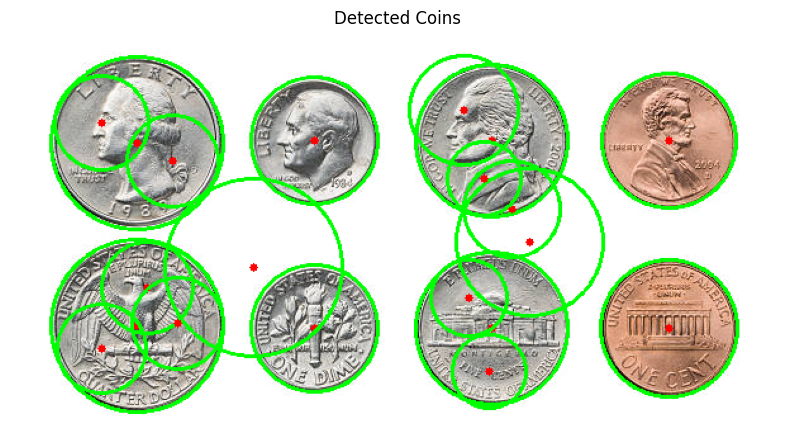

In [12]:
# ============================================================
# TASK 7
# COINS DETECTION AND COUNTING
# USING HOUGH CIRCLE TRANSFORM
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# STEP 1: READ IMAGE
# ------------------------------------------------------------

# Read the coins image.
#
# "coins.jpg" = image file name/path.
#
# If the image cannot be found, cv2.imread()
# returns None.

image = cv2.imread("coins.jpg")


# Check if image was successfully loaded.

if image is None:

    print("Coins image not found!")

else:

    # Make a copy of the original image.
    #
    # We will draw detected circles on this copy
    # so that the original image remains unchanged.

    output = image.copy()


    # --------------------------------------------------------
    # STEP 2: GRAYSCALE
    # --------------------------------------------------------

    # Convert BGR color image to grayscale.
    #
    # Hough Circle Transform works with grayscale
    # intensity/edge information.
    #
    # Grayscale pixel values:
    # 0   = black
    # 255 = white

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # --------------------------------------------------------
    # STEP 3: GAUSSIAN BLUR
    # --------------------------------------------------------

    # Blur the image to reduce noise.
    #
    # Noise can create unwanted edges and false circles.
    #
    # Parameters:
    #
    # gray = input image
    #
    # (9, 9) = Gaussian kernel size
    #
    # Larger kernel:
    # -> more smoothing
    # -> more noise reduction
    # -> but small details may be lost
    #
    # Smaller kernel:
    # -> less smoothing
    # -> more details
    # -> more noise may remain
    #
    # 2 = sigmaX
    #
    # Higher sigma generally means more smoothing.

    gray = cv2.GaussianBlur(
        gray,
        (9, 9),
        2
    )
    # --------------------------------------------------------
    # STEP 4: HOUGH CIRCLE TRANSFORM
    # --------------------------------------------------------
    # HoughCircles detects circular objects.
    #
    # Each detected circle is represented as:
    #
    # (x, y, r)
    #
    # x = center x-coordinate
    # y = center y-coordinate
    # r = radius of circle

    circles = cv2.HoughCircles(

        gray,

        # ----------------------------------------------------
        # METHOD
        # ----------------------------------------------------

        cv2.HOUGH_GRADIENT,

        # HOUGH_GRADIENT is the commonly used method
        # for detecting circles.


        # ----------------------------------------------------
        # dp = 1
        # ----------------------------------------------------

        dp=1,

        # dp controls accumulator resolution.
        #
        # dp = 1:
        # accumulator has approximately the same
        # resolution as the input image.
        #
        # Higher dp:
        # -> lower accumulator resolution
        # -> can reduce computation
        # -> may reduce detection precision
        #
        # 1 is a common starting value.


        # ----------------------------------------------------
        # minDist = 30
        # ----------------------------------------------------

        minDist=30,

        # Minimum distance between centers of detected circles.
        #
        # If two detected circle centers are closer than
        # this distance, one detection may be suppressed.
        #
        # Lower minDist:
        # -> nearby circles can both be detected
        # -> duplicate detections may increase
        #
        # Higher minDist:
        # -> nearby circles may be suppressed
        #
        # For coins that are very close together,
        # do not use an unnecessarily large value.


        # ----------------------------------------------------
        # param1 = 100
        # ----------------------------------------------------

        param1=100,

        # param1 is the HIGH threshold used by the internal
        # Canny edge detector.
        #
        # Higher param1:
        # -> stronger edges are required
        # -> fewer edges
        #
        # Lower param1:
        # -> more edges
        # -> more noise/false detections possible
        #
        # For param1 = 100:
        # the lower Canny threshold is approximately 50.


        # ----------------------------------------------------
        # param2 = 30
        # ----------------------------------------------------

        param2=30,

        # param2 is the Hough Circle accumulator threshold.
        #
        # This controls how STRICT the circle detection is.
        #
        # HIGHER param2:
        # -> stricter detection
        # -> fewer circles
        # -> fewer false circles
        #
        # LOWER param2:
        # -> more sensitive detection
        # -> more circles
        # -> more false circles possible
        #
        # If coins are NOT being detected:
        # try LOWER values such as:
        # 25 or 20
        #
        # If TOO MANY fake circles are detected:
        # try HIGHER values such as:
        # 35 or 40


        # ----------------------------------------------------
        # minRadius = 15
        # ----------------------------------------------------

        minRadius=15,

        # Minimum allowed radius of a detected circle.
        #
        # Circles smaller than 15 pixels are ignored.
        #
        # Lower value:
        # -> smaller circles can be detected
        #
        # Higher value:
        # -> smaller circles are rejected


        # ----------------------------------------------------
        # maxRadius = 100
        # ----------------------------------------------------

        maxRadius=100

        # Maximum allowed radius.
        #
        # Circles larger than 100 pixels are ignored.
        #
        # Lower value:
        # -> large circles may be rejected
        #
        # Higher value:
        # -> larger circles can be detected
    )


    # --------------------------------------------------------
    # STEP 5: CHECK IF CIRCLES WERE FOUND
    # --------------------------------------------------------

    # If HoughCircles does not detect anything,
    # circles will be None.

    if circles is not None:


        # ----------------------------------------------------
        # STEP 6: CONVERT VALUES TO INTEGER
        # ----------------------------------------------------

        # HoughCircles may return floating-point values.
        #
        # Example:
        #
        # [120.7, 200.3, 45.8]
        #
        # We round these values and convert them to integers
        # because image coordinates are easier to use as integers.

        circles = np.round(
            circles[0, :]
        ).astype("int")


        # ----------------------------------------------------
        # STEP 7: COUNT COINS
        # ----------------------------------------------------

        # Each detected circle is assumed to represent
        # one coin.
        #
        # len(circles) gives the total number of detected circles.

        count = len(circles)

        print(
            "Number of coins:",
            count
        )


        # ----------------------------------------------------
        # STEP 8: DRAW DETECTED CIRCLES
        # ----------------------------------------------------

        # Process every detected circle.

        for x, y, r in circles:

            # ------------------------------------------------
            # DRAW CIRCLE BOUNDARY
            # ------------------------------------------------

            # Draw the detected coin boundary.
            #
            # Parameters:
            #
            # output       = image on which to draw
            # (x, y)       = center of circle
            # r            = radius
            # (0,255,0)    = GREEN in BGR format
            # 2            = thickness

            cv2.circle(
                output,
                (x, y),
                r,
                (0, 255, 0),
                2
            )


            # ------------------------------------------------
            # DRAW CENTER POINT
            # ------------------------------------------------

            # Draw a small RED point at the center.
            #
            # (0,0,255) = RED in BGR format
            #
            # -1 = filled circle

            cv2.circle(
                output,
                (x, y),
                3,
                (0, 0, 255),
                -1
            )


    else:

        # If no circles were detected.

        print("No coins detected.")


    # --------------------------------------------------------
    # STEP 9: BGR TO RGB
    # --------------------------------------------------------

    # OpenCV uses BGR format.
    # Matplotlib expects RGB format.
    #
    # Therefore convert BGR -> RGB before displaying.

    output_rgb = cv2.cvtColor(
        output,
        cv2.COLOR_BGR2RGB
    )


    # --------------------------------------------------------
    # STEP 10: DISPLAY RESULT
    # --------------------------------------------------------

    # Set figure size.

    plt.figure(figsize=(10, 7))


    # Display detected coins.

    plt.imshow(output_rgb)


    # Title.

    plt.title(
        "Detected Coins"
    )


    # Hide axis numbers.

    plt.axis("off")


    # Show final result.

    plt.show()

In [ ]:
# ============================================================
# TASK 8
# SMART SECURITY SYSTEM
# BOUNDARY DETECTION
# ============================================================

import cv2
# ============================================================
# STEP 1: OPEN CAMERA / VIDEO
# ============================================================
# ------------------------------------------------------------
# OPTION 1: OPEN WEBCAM
# ------------------------------------------------------------
# 0 usually computer ka default webcam hota hai.
#
# Agar multiple cameras connected hon:
#
# cv2.VideoCapture(0)  -> first/default camera
# cv2.VideoCapture(1)  -> second camera
# cv2.VideoCapture(2)  -> third camera
#
# Webcam use karni ho to ye line uncomment rakhein:
cap = cv2.VideoCapture(0)
# ------------------------------------------------------------
# OPTION 2: LOAD SAVED VIDEO FILE
# ------------------------------------------------------------
# Agar webcam ki jagah already saved video process karni ho,
# to upar wali webcam line ko comment kar dein:
#
# cap = cv2.VideoCapture(0)
#
# Aur video file ka naam/path dein:
#
# cap = cv2.VideoCapture("security_video.mp4")
#
# Example:
#
# cap = cv2.VideoCapture("road_video.mp4")
#
# Agar video kisi folder mein ho:
#
# cap = cv2.VideoCapture("videos/security_video.mp4")
#
# Windows path example:
#
# cap = cv2.VideoCapture(r"C:\Users\YourName\Videos\security_video.mp4")
#
# IMPORTANT:
# r"..." use karna useful hai taake Windows ke
# backslashes (\) ko Python escape character na samjhe.
#
# Webcam aur saved video dono mein baaki code SAME rahega.
# Sirf VideoCapture() ka source change hota hai.


# Check whether camera/video opened successfully.

if not cap.isOpened():

    print("Camera or video could not be opened.")

else:

    while True:

        # ----------------------------------------------------
        # STEP 2: READ ONE VIDEO FRAME
        # ----------------------------------------------------

        # cap.read() video/camera se ek frame read karta hai.
        #
        # ret:
        # True  -> frame successfully read hua
        # False -> frame read nahi hua / video khatam ho gayi
        #
        # frame:
        # Actual image/frame jo camera ya video se mila.

        ret, frame = cap.read()


        if not ret:

            print("Could not read frame.")
            break


        # ----------------------------------------------------
        # STEP 3: GRAYSCALE
        # ----------------------------------------------------

        # Color image ko grayscale mein convert karte hain.
        #
        # Grayscale mein sirf intensity information hoti hai.
        #
        # Pixel values:
        # 0   = black
        # 255 = white
        #
        # Edge detection ke liye grayscale useful hai.

        gray = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2GRAY
        )


        # ----------------------------------------------------
        # STEP 4: GAUSSIAN BLUR
        # ----------------------------------------------------

        # Blur image se noise reduce karta hai.
        #
        # Noise ki wajah se unnecessary edges/contours
        # detect ho sakte hain.
        #
        # (5,5) = Gaussian kernel size.
        #
        # Larger kernel:
        # -> zyada smoothing
        # -> zyada noise reduction
        # -> lekin small details lose ho sakti hain
        #
        # Smaller kernel:
        # -> kam smoothing
        # -> zyada details
        # -> noise bhi zyada reh sakta hai
        #
        # 0 = sigmaX automatically calculate hoga.

        blurred = cv2.GaussianBlur(
            gray,
            (5, 5),
            0
        )


        # ----------------------------------------------------
        # STEP 5: EDGE DETECTION
        # ----------------------------------------------------

        # Canny image mein edges detect karta hai.
        #
        # 50 = lower threshold
        # 150 = upper threshold
        #
        # Lower thresholds:
        # -> zyada edges detect ho sakti hain
        # -> noise/false edges bhi increase ho sakti hain
        #
        # Higher thresholds:
        # -> sirf stronger edges detect hongi
        # -> weak edges miss ho sakti hain

        edges = cv2.Canny(
            blurred,
            50,
            150
        )


        # ----------------------------------------------------
        # STEP 6: FIND OBJECT CONTOURS
        # ----------------------------------------------------

        # findContours edges se object boundaries/contours
        # find karta hai.
        #
        # contours:
        # -> detected object boundaries
        #
        # hierarchy:
        # -> contours ke parent/child relationships
        #
        # RETR_EXTERNAL:
        # -> sirf outermost/external contours detect karo
        #
        # CHAIN_APPROX_SIMPLE:
        # -> unnecessary contour points ko remove karke
        #    memory save karta hai.

        contours, hierarchy = cv2.findContours(
            edges,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )


        # ----------------------------------------------------
        # STEP 7: DEFINE SECURITY ZONE
        # ----------------------------------------------------

        # Frame ki height aur width nikal rahe hain.
        #
        # frame.shape:
        # (height, width, channels)
        #
        # [:2]:
        # sirf height aur width leta hai.

        height, width = frame.shape[:2]


        # ----------------------------------------------------
        # SECURITY ZONE
        # ----------------------------------------------------

        # Security zone image ke center mein banaya gaya hai.
        #
        # x1 = left boundary
        # y1 = top boundary
        # x2 = right boundary
        # y2 = bottom boundary
        #
        # 0.25 = width/height ka 25%
        # 0.75 = width/height ka 75%
        #
        # Iska matlab security rectangle:
        #
        # left   = 25% of image width
        # right  = 75% of image width
        # top    = 25% of image height
        # bottom = 75% of image height
        #
        # Isliye center ka approximately 50% area
        # security zone ban jata hai.

        x1 = int(width * 0.25)
        y1 = int(height * 0.25)

        x2 = int(width * 0.75)
        y2 = int(height * 0.75)


        # ----------------------------------------------------
        # DRAW SECURITY ZONE
        # ----------------------------------------------------

        # Security zone ke around rectangle draw karte hain.
        #
        # (255,0,0) = BLUE in OpenCV BGR format
        # 2 = line thickness

        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )


        # ----------------------------------------------------
        # STEP 8: CHECK EACH OBJECT
        # ----------------------------------------------------

        # Initially assume karte hain ke security zone clear hai.

        unauthorized_object = False


        # Har detected contour ko one-by-one check karenge.

        for contour in contours:


            # ------------------------------------------------
            # REMOVE SMALL NOISE
            # ------------------------------------------------

            # contourArea() detected contour ka area calculate
            # karta hai.
            #
            # Small area usually noise ho sakta hai.
            #
            # 500 = minimum accepted contour area.
            #
            # Agar area < 500:
            # -> contour ko ignore kar do.
            #
            # Agar threshold increase karein:
            # -> aur small objects/noise ignore honge
            # -> lekin small real objects bhi miss ho sakte hain
            #
            # Agar threshold decrease karein:
            # -> small objects detect ho sakte hain
            # -> noise bhi zyada detect ho sakta hai.

            area = cv2.contourArea(
                contour
            )


            if area < 500:

                continue


            # ------------------------------------------------
            # BOUNDING RECTANGLE
            # ------------------------------------------------

            # Object ke around ek rectangular box banane ke liye
            # boundingRect() use hota hai.
            #
            # x, y = rectangle ka top-left corner
            # w    = rectangle ki width
            # h    = rectangle ki height

            x, y, w, h = cv2.boundingRect(
                contour
            )


            # ------------------------------------------------
            # OBJECT CENTER
            # ------------------------------------------------

            # Bounding rectangle ka center calculate kar rahe hain.
            #
            # x + w//2 = center x
            # y + h//2 = center y
            #
            # // = integer division

            center_x = x + w // 2
            center_y = y + h // 2


            # ------------------------------------------------
            # CHECK WHETHER OBJECT IS INSIDE SECURITY ZONE
            # ------------------------------------------------

            # Check karte hain ke object ka center
            # security rectangle ke andar hai ya nahi.
            #
            # x1 < center_x < x2
            # -> center horizontally zone ke andar hai
            #
            # y1 < center_y < y2
            # -> center vertically zone ke andar hai
            #
            # Dono conditions TRUE hon:
            # -> object security zone ke andar hai.

            if (
                x1 < center_x < x2
                and
                y1 < center_y < y2
            ):

                # Object security zone mein mil gaya.
                #
                # Isliye alarm activate karenge.

                unauthorized_object = True


                # ------------------------------------------------
                # DRAW OBJECT BOUNDARY
                # ------------------------------------------------

                # Object ke around RED bounding box draw karte hain.
                #
                # (0,0,255) = RED in BGR format
                # 2 = thickness

                cv2.rectangle(
                    frame,
                    (x, y),
                    (x + w, y + h),
                    (0, 0, 255),
                    2
                )


        # ----------------------------------------------------
        # STEP 9: ALARM
        # ----------------------------------------------------

        # Agar security zone ke andar object mila:

        if unauthorized_object:

            # Red warning message show karein.

            cv2.putText(
                frame,

                "ALARM! OBJECT IN SECURITY ZONE",

                # Text ki starting position.
                (30, 50),

                # Font type.
                cv2.FONT_HERSHEY_SIMPLEX,

                # Font size.
                0.8,

                # RED color in BGR.
                (0, 0, 255),

                # Text thickness.
                2
            )


        else:

            # Agar security zone mein koi object nahi mila,
            # to green message show karein.

            cv2.putText(
                frame,

                "SECURITY ZONE CLEAR",

                (30, 50),

                cv2.FONT_HERSHEY_SIMPLEX,

                0.8,

                # GREEN in BGR.
                (0, 255, 0),

                2
            )


        # ----------------------------------------------------
        # STEP 10: SHOW FRAME
        # ----------------------------------------------------

        # Current processed frame ko window mein display karein.
        #
        # "Smart Security System" = window ka title

        cv2.imshow(
            "Smart Security System",
            frame
        )


        # ----------------------------------------------------
        # STEP 11: PRESS q TO EXIT
        # ----------------------------------------------------

        # waitKey(1):
        # 1 millisecond ke liye keyboard input check karta hai.
        #
        # & 0xFF:
        # keyboard value ko properly extract karne ke liye
        # commonly use hota hai.
        #
        # ord("q"):
        # letter q ka keyboard code.
        #
        # Agar user q press kare:
        # -> loop break
        # -> camera/video processing stop

        if cv2.waitKey(1) & 0xFF == ord("q"):

            break


    # --------------------------------------------------------
    # STEP 12: RELEASE CAMERA / VIDEO
    # --------------------------------------------------------

    # Camera/video resource release karte hain.

    cap.release()


    # OpenCV ki sari windows close karte hain.

    cv2.destroyAllWindows()

| Parameter       | Kya karta hai                                                                                           |
| --------------- | ------------------------------------------------------------------------------------------------------- |
| `RETR_EXTERNAL` | Sirf outermost contours                                                                                 |
| `RETR_LIST`     | External + internal **sab contours**, but hierarchy parent-child relation properly establish nahi karta |
| `RETR_CCOMP`    | Contours ko 2-level hierarchy mein arrange karta hai                                                    |
| `RETR_TREE`     | External + internal + complete parent-child hierarchy                                                   |
CHAIN_APPROX_SIMPLE
Memory kam use hoti hai
Processing efficient hoti hai
Contour data compact hota hai
Straight boundaries ke unnecessary points remove ho jaate hain
CHAIN_APPROX_NONE
Zyada complete boundary information
Lekin bohat zyada points
Memory/processing zyada

In [2]:
!pip install PyWavelets

   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.3 MB ? eta -:--:--
   --------- ------------------------------ 1.0/4.3 MB 3.9 MB/s eta 0:00:01
   -------------- ------------------------- 1.6/4.3 MB 3.1 MB/s eta 0:00:01
   ----------------- ---------------------- 1.8/4.3 MB 2.9 MB/s eta 0:00:01
   ---------------------- ----------------- 2.4/4.3 MB 2.6 MB/s eta 0:00:01
   ---------------------- ----------------- 2.4/4.3 MB 2.6 MB/s eta 0:00:01
   ---------------------- ----------------- 2.4/4.3 MB 2.6 MB/s eta 0:00:01
   ---------------------- ----------------- 2.4/4.3 MB 2.6 MB/s eta 0:00:01
   ------------------------------------ --- 3.9/4.3 MB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 2.2 MB/s  0:00:02



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Number of detected anomalies: 5


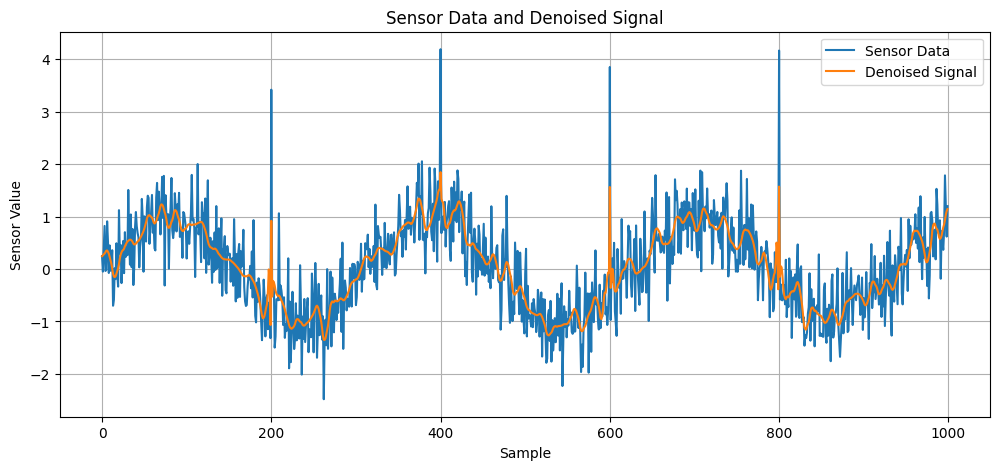

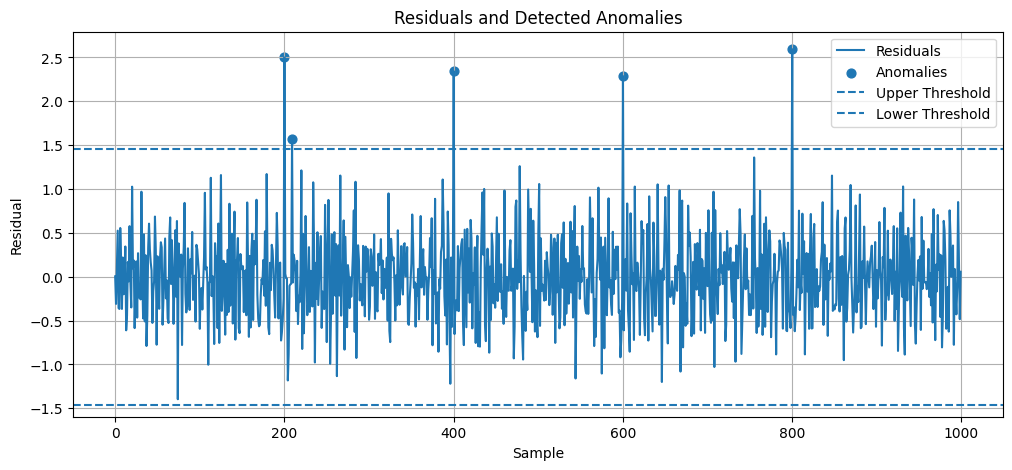

In [3]:
# ============================================================
# TASK
# ANOMALY DETECTION IN SENSOR DATA
# USING WAVELET TRANSFORMATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pywt


# ============================================================
# STEP 1: CREATE SAMPLE SENSOR DATA
# ============================================================

# Number of sensor readings.

n = 1000


# Random generator.
#
# Seed fix karne se har baar same random data generate hoga.
# Isse result repeatable/reproducible rehta hai.

np.random.seed(42)


# ------------------------------------------------------------
# NORMAL SENSOR SIGNAL
# ------------------------------------------------------------

# Hum ek simple smooth signal bana rahe hain.
#
# np.linspace(0, 20, n):
# 0 se 20 tak n values create karega.
#
# np.sin():
# smooth wave create karega.

t = np.linspace(
    0,
    20,
    n
)

normal_signal = np.sin(t)


# ------------------------------------------------------------
# ADD SENSOR NOISE
# ------------------------------------------------------------

# Random Gaussian noise generate karte hain.
#
# 0 = mean
# 0.5 = standard deviation
#
# 0.5 ko increase karein:
# -> zyada noisy data
#
# 0.5 ko decrease karein:
# -> cleaner data

noise = np.random.normal(
    0,
    0.5,
    n
)


# Sensor data = normal signal + noise

sensor_data = normal_signal + noise


# ============================================================
# STEP 2: ADD ARTIFICIAL ANOMALIES
# ============================================================

# Real sensor systems mein anomalies unusual values hoti hain.
#
# Demonstration ke liye hum kuch artificial spikes add karenge.

anomaly_indices = [
    200,
    400,
    600,
    800
]


# Har selected location par large value add kar rahe hain.

sensor_data[anomaly_indices] += 4


# Ab sensor_data mein:
#
# normal signal
# +
# random noise
# +
# abnormal spikes
#
# present hain.


# ============================================================
# STEP 3: WAVELET DECOMPOSITION
# ============================================================

# Wavelet select kar rahe hain.
#
# 'db4' = Daubechies wavelet with 4 vanishing moments.
#
# db4 commonly signal processing mein use hota hai.

wavelet = "db4"


# Wavelet decomposition level.
#
# Level 3 ka matlab signal ko multiple scales
# par analyze karna.

level = 3


# wavedec() signal ko wavelet coefficients mein
# decompose karta hai.

coefficients = pywt.wavedec(
    sensor_data,
    wavelet,
    level=level
)


# ============================================================
# STEP 4: ESTIMATE NOISE
# ============================================================

# Sabse high-frequency detail coefficients:
#
# coefficients[-1]
#
# mein usually noise information zyada hoti hai.

detail_coefficients = coefficients[-1]


# Median Absolute Deviation (MAD) use karke
# noise ka estimate nikal rahe hain.
#
# 0.6745 wavelet denoising mein commonly used
# scaling constant hai.

sigma = (
    np.median(
        np.abs(detail_coefficients)
    )
    / 0.6745
)


# ============================================================
# STEP 5: CALCULATE THRESHOLD
# ============================================================

# Universal threshold.
#
# Ye decide karega ke detail coefficient
# kitna large hona chahiye before we consider it important.

threshold = (
    sigma
    * np.sqrt(
        2 * np.log(len(sensor_data))
    )
)


# ============================================================
# STEP 6: THRESHOLD WAVELET COEFFICIENTS
# ============================================================

# Har detail coefficient ko threshold karenge.
#
# pywt.threshold():
#
# threshold se choti values ko reduce/zero karta hai.
#
# mode="soft":
# values ko smoothly shrink karta hai.

for i in range(1, len(coefficients)):

    coefficients[i] = pywt.threshold(
        coefficients[i],
        threshold,
        mode="soft"
    )


# ============================================================
# STEP 7: RECONSTRUCT DENOISED SIGNAL
# ============================================================

# Thresholded wavelet coefficients se
# clean/denoised signal reconstruct kar rahe hain.

denoised_signal = pywt.waverec(
    coefficients,
    wavelet
)


# waverec() kabhi kabhi original length se
# 1-2 samples zyada return kar sakta hai.
#
# Isliye original sensor_data ke length ke
# according crop kar rahe hain.

denoised_signal = denoised_signal[
    :len(sensor_data)
]


# ============================================================
# STEP 8: CALCULATE RESIDUAL
# ============================================================

# Residual = Original sensor data - denoised signal
#
# Agar original aur denoised almost same hain:
# -> residual small
#
# Agar original mein unusual spike hai:
# -> residual large

residual = (
    sensor_data
    - denoised_signal
)


# ============================================================
# STEP 9: DETERMINE ANOMALY THRESHOLD
# ============================================================

# Residuals ke standard deviation ko calculate karte hain.

residual_std = np.std(
    residual
)


# 3-sigma rule.
#
# threshold = 3 × standard deviation
#
# Usually residual agar ±3 standard deviations
# se bahar chala jaye to suspicious/anomaly
# consider kar sakte hain.

anomaly_threshold = (
    3 * residual_std
)


# ============================================================
# STEP 10: DETECT ANOMALIES
# ============================================================

# abs() negative residual ko bhi positive magnitude
# mein convert karta hai.
#
# Example:
#
# residual = -5
# abs(-5) = 5
#
# residual = +5
# abs(+5) = 5
#
# Dono large deviations hain.

anomalies = (
    np.abs(residual)
    > anomaly_threshold
)


# ============================================================
# STEP 11: GET ANOMALY POSITIONS
# ============================================================

# np.where() un positions ko return karta hai
# jahan anomalies == True hai.

anomaly_positions = np.where(
    anomalies
)[0]


# Number of detected anomalies.

print(
    "Number of detected anomalies:",
    len(anomaly_positions)
)


# ============================================================
# STEP 12: PLOT SENSOR DATA AND DENOISED SIGNAL
# ============================================================

plt.figure(
    figsize=(12, 5)
)


# Original noisy sensor data.

plt.plot(
    sensor_data,
    label="Sensor Data"
)


# Wavelet-denoised signal.

plt.plot(
    denoised_signal,
    label="Denoised Signal"
)


plt.title(
    "Sensor Data and Denoised Signal"
)

plt.xlabel(
    "Sample"
)

plt.ylabel(
    "Sensor Value"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# STEP 13: PLOT RESIDUALS AND ANOMALIES
# ============================================================

plt.figure(
    figsize=(12, 5)
)


# Plot residuals.

plt.plot(
    residual,
    label="Residuals"
)


# Plot detected anomalies as points.
#
# sensor_data[anomalies]
# gives original sensor values at anomaly positions.

plt.scatter(
    anomaly_positions,
    residual[anomaly_positions],
    label="Anomalies",
    s=40
)


# Show positive anomaly threshold.

plt.axhline(
    anomaly_threshold,
    linestyle="--",
    label="Upper Threshold"
)


# Show negative anomaly threshold.

plt.axhline(
    -anomaly_threshold,
    linestyle="--",
    label="Lower Threshold"
)


plt.title(
    "Residuals and Detected Anomalies"
)

plt.xlabel(
    "Sample"
)

plt.ylabel(
    "Residual"
)

plt.legend()

plt.grid()

plt.show()